<a href="https://colab.research.google.com/github/D2718281828nis/BioMedAI-Heart-Desease-LifeTime-Forecast/blob/main/Survival-function-analysys.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Load libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve

from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC

import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline

# Load dataset

In [2]:
data_link = "https://github.com/D2718281828nis/BioMedAI-Heart-Desease-LifeTime-Forecast/raw/refs/heads/main/med_dataset_cardio.xlsx"
data = pd.read_excel(data_link, header=0)
data.rename(columns={"0_na, 1_mi": "severity", "0_no, 1_ther, 2_card": "doctor"}, inplace=True);
data.drop(columns=["card"], inplace=True)
data.drop(columns=["na"], inplace=True)
data.drop(columns=["dmonit"], inplace=True)
data["target"] = data["result_cvd"]
data.drop(columns=["result", "result_cvd"], inplace=True)

from sklearn.utils import resample
from imblearn.over_sampling import SMOTE

df_raw = data.copy()

# Separate majority and minority classes
df_majority = df_raw[df_raw['target'] == 0]
df_minority = df_raw[df_raw['target'] == 1]

print(f"\nClass 0 samples: {len(df_majority)}")
print(f"Class 1 samples: {len(df_minority)}")


Class 0 samples: 1354
Class 1 samples: 152


In [18]:
df = df_raw
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1506 entries, 0 to 1505
Data columns (total 32 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   doctor        1506 non-null   int64  
 1   time          1506 non-null   int64  
 2   age           1506 non-null   float64
 3   af            1506 non-null   int64  
 4   dm            1506 non-null   int64  
 5   ckd           1506 non-null   int64  
 6   copd          1506 non-null   int64  
 7   insult        1506 non-null   int64  
 8   onco          1506 non-null   int64  
 9   severity      1506 non-null   int64  
 10  nstemi        1506 non-null   int64  
 11  stemi         1506 non-null   int64  
 12  llo           1506 non-null   int64  
 13  gender        1506 non-null   int64  
 14  ca_delay      1506 non-null   int64  
 15  sum_cad       1506 non-null   int64  
 16  stenting      1506 non-null   int64  
 17  total_revasc  1506 non-null   int64  
 18  ef_hosp       1506 non-null 

In [20]:
y = df['time']

columns_to_drop_for_regressor = ['time', 'target']

#if 'age_group' in df_upsampled.columns:
#    columns_to_drop_for_regressor.append('age_group')

X = df.drop(columns=columns_to_drop_for_regressor)

In [21]:
# Store the feature names that gb_reg was trained on
original_gb_reg_features = X.columns.tolist()

#делим выборку на тестовую и тренировочную
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=37
)

#данные имеют разную природу, поэтому нужно их стандартизовать
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")

Train: (1204, 30)  |  Test: (302, 30)


## Method 1: Downsample majority class to match minority class

In [3]:

# Method 1: Downsample majority class to match minority class
df_majority_downsampled = resample(df_majority,
                                   replace=False,  # sample without replacement
                                   n_samples=len(df_minority),  # match minority class size
                                   random_state=37)  # reproducible results

# Combine downsampled majority with minority
df_downsampled = pd.concat([df_majority_downsampled, df_minority])

print(f"\nAfter downsampling - balanced dataset:")
print(df_downsampled['target'].value_counts())
print(f"Total samples after downsampling: {len(df_downsampled)}")


After downsampling - balanced dataset:
target
0    152
1    152
Name: count, dtype: int64
Total samples after downsampling: 304


In [4]:
y = df_downsampled['time']

columns_to_drop_for_regressor = ['time', 'target']

#if 'age_group' in df_upsampled.columns:
#    columns_to_drop_for_regressor.append('age_group')

X = df_downsampled.drop(columns=columns_to_drop_for_regressor)

In [5]:
# Store the feature names that gb_reg was trained on
original_gb_reg_features = X.columns.tolist()

#делим выборку на тестовую и тренировочную
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=37
)

#данные имеют разную природу, поэтому нужно их стандартизовать
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")

Train: (243, 30)  |  Test: (61, 30)


In [6]:
df = df_downsampled

## Method 2: Upsample minority class using SMOTE to match majority class

In [7]:
# Method 2: Upsample minority class using SMOTE to match majority class
# Prepare data for SMOTE: features and target
X_smote = df_raw.drop('target', axis=1)
y_smote = df_raw['target']

smote = SMOTE(random_state=37)
X_resampled, y_resampled = smote.fit_resample(X_smote, y_smote)

# Combine resampled features and target into a new DataFrame
df_upsampled = pd.concat([X_resampled, y_resampled], axis=1)

print(f"\nAfter upsampling with SMOTE - balanced dataset:")
print(df_upsampled['target'].value_counts())
print(f"Total samples after upsampling: {len(df_upsampled)}")


After upsampling with SMOTE - balanced dataset:
target
0    1354
1    1354
Name: count, dtype: int64
Total samples after upsampling: 2708


In [8]:
y = df_upsampled['time']

columns_to_drop_for_regressor = ['time', 'target']

#if 'age_group' in df_upsampled.columns:
#    columns_to_drop_for_regressor.append('age_group')

X = df_upsampled.drop(columns=columns_to_drop_for_regressor)

In [9]:
# Store the feature names that gb_reg was trained on
original_gb_reg_features = X.columns.tolist()

#делим выборку на тестовую и тренировочную
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=37
)

#данные имеют разную природу, поэтому нужно их стандартизовать
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")

Train: (2166, 30)  |  Test: (542, 30)


In [10]:
df = df_upsampled

# 0. Решаем задачу регрессии для time

In [22]:
# линейная регрессия
lr = LinearRegression()
lr.fit(X_train_sc, y_train)

y_pred_lr = lr.predict(X_test_sc)

lr_r2   = r2_score(y_test, y_pred_lr)
lr_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
lr_mae  = mean_absolute_error(y_test, y_pred_lr)

print("Linear Regression")
print(f"  R²   = {lr_r2:.4f}")
print(f"  RMSE = {lr_rmse:.4f}")
print(f"  MAE  = {lr_mae:.4f}")
print(f"\nКоэффициенты модели:")
coef_df = pd.DataFrame({'feature': X.columns, 'coef': lr.coef_}).sort_values('coef')
print(coef_df.to_string(index=False))

Linear Regression
  R²   = 0.2209
  RMSE = 353.1533
  MAE  = 272.1643

Коэффициенты модели:
     feature        coef
      nstemi -135.182021
       stemi -129.190269
        crea  -54.530000
         glu  -51.712830
   pulm_cong  -45.655542
         age  -42.573623
         ldl  -34.444124
         llo  -24.267913
         bpm  -21.334244
      leukoc  -18.771685
          af  -15.686870
      insult  -14.940345
     sum_cad  -14.472986
      gender   -9.913432
     smoking   -4.852558
     tromboc   -1.543801
        copd   -0.490114
        onco   -0.195656
          dm    1.795672
    ca_delay    3.275578
         bmi    6.828807
    stenting    8.355250
         ckd   10.198491
       sysAP   11.194829
total_revasc   19.186510
          hb   37.904659
     ef_hosp   41.819104
      t_chol   92.066158
      doctor   95.404234
    severity  126.073032


In [23]:
# деревья решений
dt_reg = DecisionTreeRegressor(random_state=37, max_depth=10)
dt_reg.fit(X_train_sc, y_train)

y_pred_dt = dt_reg.predict(X_test_sc)

dt_r2   = r2_score(y_test, y_pred_dt)
dt_rmse = np.sqrt(mean_squared_error(y_test, y_pred_dt))
dt_mae  = mean_absolute_error(y_test, y_pred_dt)

# Train vs Test — проверяем переобучение
dt_r2_train = r2_score(y_train, dt_reg.predict(X_train_sc))

print("Decision Tree (max_depth=10)")
print(f"  Train R² = {dt_r2_train:.4f}")
print(f"  Test  R² = {dt_r2:.4f}")
print(f"  RMSE     = {dt_rmse:.4f}")
print(f"  MAE      = {dt_mae:.4f}")
if dt_r2_train - dt_r2 > 0.1:
    print("Внимание: разрыв Train/Test > 0.1 — возможно переобучение!")

Decision Tree (max_depth=10)
  Train R² = 0.8244
  Test  R² = -0.4570
  RMSE     = 482.9618
  MAE      = 333.0067
Внимание: разрыв Train/Test > 0.1 — возможно переобучение!


Random Forest (100 деревьев, max_depth=10)
  R²   = 0.2020
  RMSE = 357.4280
  MAE  = 272.5464


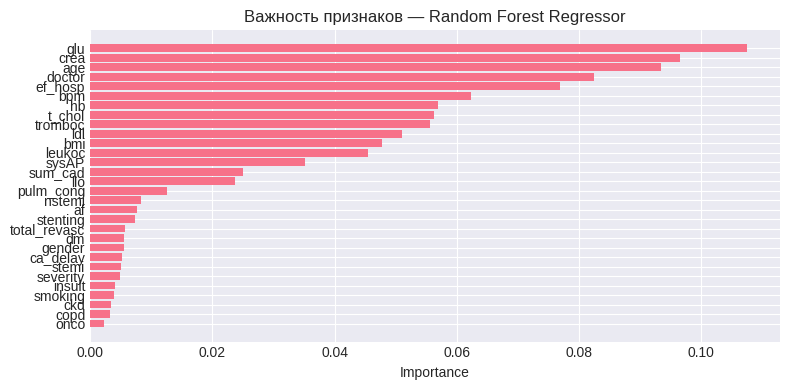

In [24]:
# случайный лес
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42, max_depth=10)
rf_reg.fit(X_train_sc, y_train)

y_pred_rf = rf_reg.predict(X_test_sc)

rf_r2   = r2_score(y_test, y_pred_rf)
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
rf_mae  = mean_absolute_error(y_test, y_pred_rf)

print("Random Forest (100 деревьев, max_depth=10)")
print(f"  R²   = {rf_r2:.4f}")
print(f"  RMSE = {rf_rmse:.4f}")
print(f"  MAE  = {rf_mae:.4f}")

# Важность признаков
feat_imp = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_reg.feature_importances_
}).sort_values('importance', ascending=True)

plt.figure(figsize=(8, 4))
plt.barh(feat_imp['feature'], feat_imp['importance'])
plt.title('Важность признаков — Random Forest Regressor')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

Gradient Boosting (100 деревьев, max_depth=5)
  R²   = 0.1635
  RMSE = 365.9444
  MAE  = 273.7974


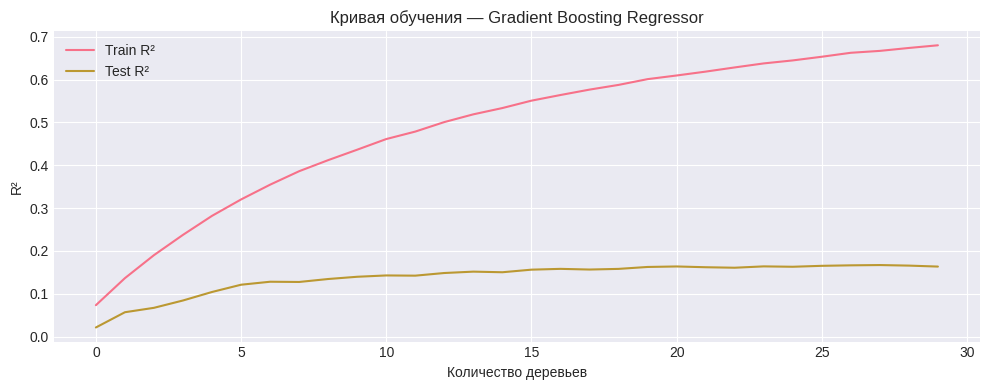

In [25]:
# градиентный бустинг
gb_reg = GradientBoostingRegressor(n_estimators=30, random_state=42, max_depth=5)
gb_reg.fit(X_train_sc, y_train)

y_pred_gb = gb_reg.predict(X_test_sc)

gb_r2   = r2_score(y_test, y_pred_gb)
gb_rmse = np.sqrt(mean_squared_error(y_test, y_pred_gb))
gb_mae  = mean_absolute_error(y_test, y_pred_gb)

print("Gradient Boosting (100 деревьев, max_depth=5)")
print(f"  R²   = {gb_r2:.4f}")
print(f"  RMSE = {gb_rmse:.4f}")
print(f"  MAE  = {gb_mae:.4f}")

# Кривая обучения (staged_predict)
train_scores = [r2_score(y_train, y_pred) for y_pred in gb_reg.staged_predict(X_train_sc)]
test_scores  = [r2_score(y_test,  y_pred) for y_pred in gb_reg.staged_predict(X_test_sc)]

plt.figure(figsize=(10, 4))
plt.plot(train_scores, label='Train R²', linewidth=1.5)
plt.plot(test_scores,  label='Test R²',  linewidth=1.5)
plt.xlabel('Количество деревьев')
plt.ylabel('R²')
plt.title('Кривая обучения — Gradient Boosting Regressor')
plt.legend()
plt.tight_layout()
plt.show()

Сводная таблица — Регрессия:
                       R²      RMSE       MAE
Model                                        
Linear Regression  0.2209  353.1533  272.1643
Decision Tree     -0.4570  482.9618  333.0067
Random Forest      0.2020  357.4280  272.5464
Gradient Boosting  0.1635  365.9444  273.7974

Лучшая модель по R²: Linear Regression (0.2209)


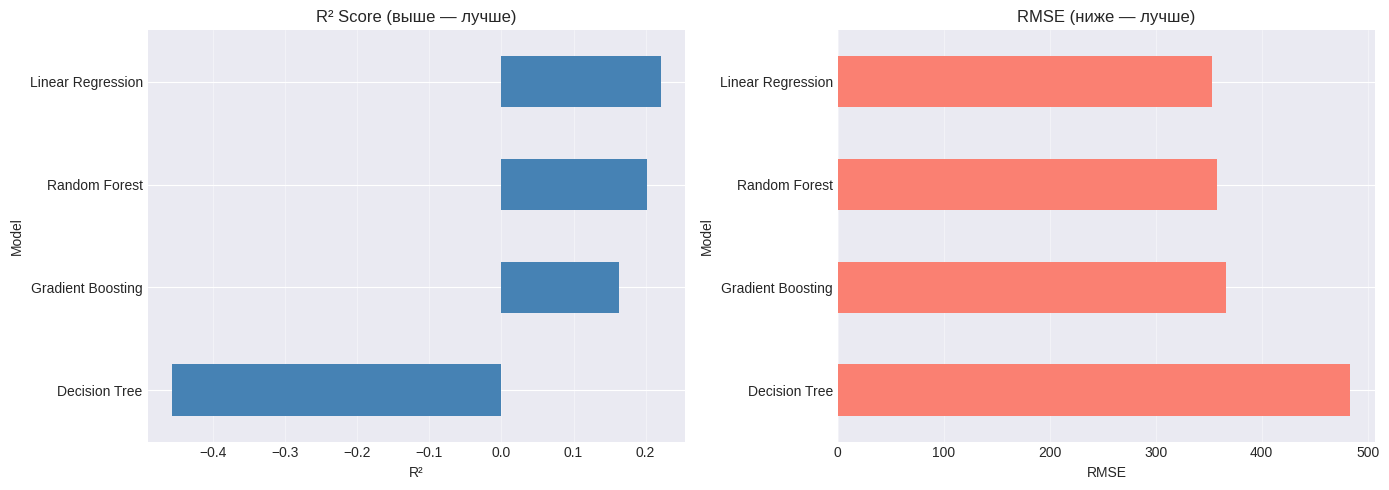

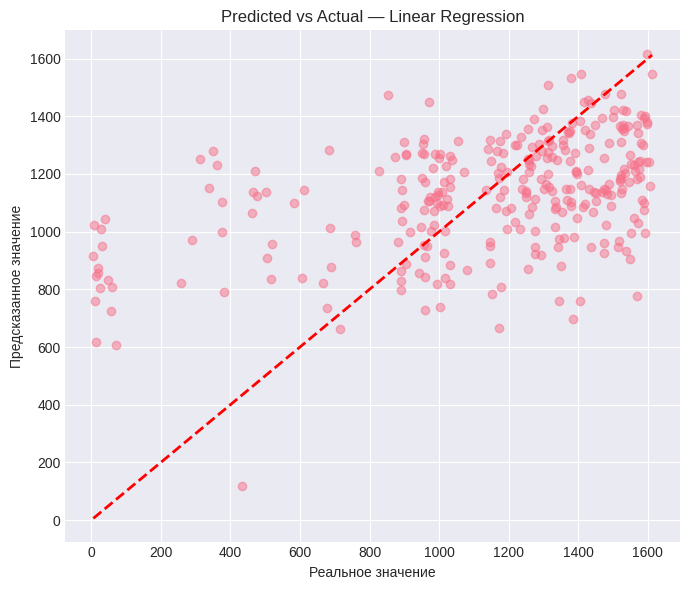

In [26]:
# сравниваем методы
reg_summary = pd.DataFrame({
    'Model': ['Linear Regression',
              'Decision Tree', 'Random Forest', 'Gradient Boosting'],
    'R²':   [lr_r2, dt_r2, rf_r2, gb_r2],
    'RMSE': [lr_rmse, dt_rmse, rf_rmse, gb_rmse],
    'MAE':  [lr_mae,  dt_mae,  rf_mae,  gb_mae]
}).set_index('Model').round(4)

print("Сводная таблица — Регрессия:")
print(reg_summary.to_string())

best_reg = reg_summary['R²'].idxmax()
print(f"\nЛучшая модель по R²: {best_reg} ({reg_summary.loc[best_reg, 'R²']:.4f})")

# График сравнения R²
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

reg_summary['R²'].sort_values().plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('R² Score (выше — лучше)')
axes[0].set_xlabel('R²')
axes[0].grid(axis='x', alpha=0.4)

reg_summary['RMSE'].sort_values(ascending=False).plot(kind='barh', ax=axes[1], color='salmon')
axes[1].set_title('RMSE (ниже — лучше)')
axes[1].set_xlabel('RMSE')
axes[1].grid(axis='x', alpha=0.4)

plt.tight_layout()
plt.show()

#для лучшей модели
best_pred_map = {
    'Linear Regression': y_pred_lr,
    'Decision Tree': y_pred_dt,
    'Random Forest': y_pred_rf,
    'Gradient Boosting': y_pred_gb
}
y_best = best_pred_map[best_reg]

plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_best, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Реальное значение')
plt.ylabel('Предсказанное значение')
plt.title(f'Predicted vs Actual — {best_reg}')
plt.tight_layout()
plt.show()

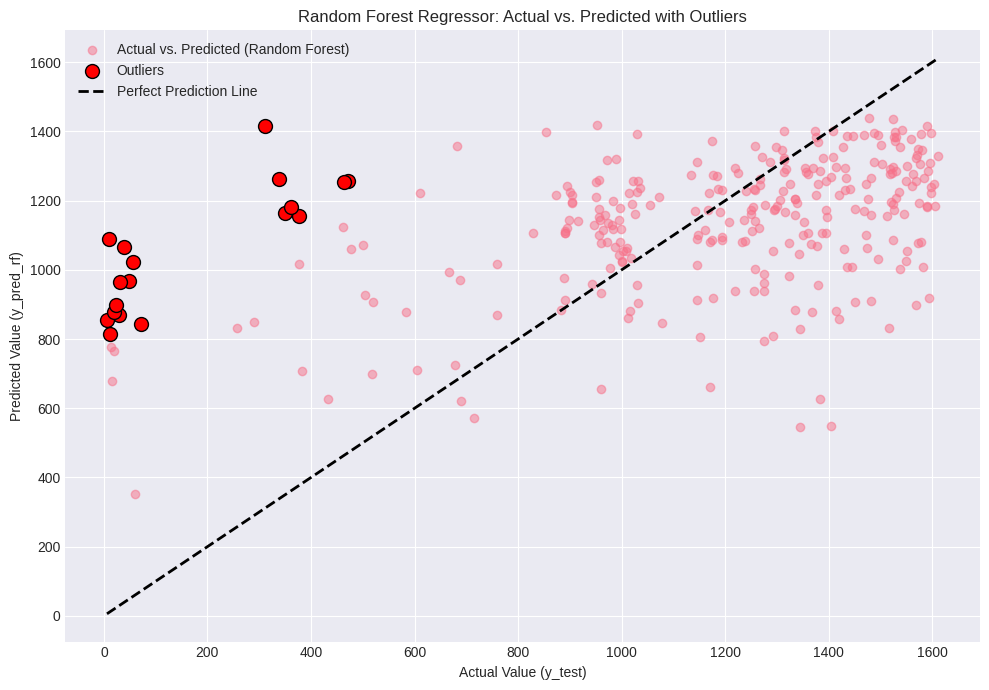


Number of outlier predictions: 18
Lower bound for residual outliers: -770.13
Upper bound for residual outliers: 857.08

--- Outlier Samples (Actual vs. Predicted) ---
      Actual    Predicted     Residual
721      338  1262.635286  -924.635286
513       72   842.512261  -770.512261
670       29   870.719082  -841.719082
812        6   854.303621  -848.303621
1091      49   967.038320  -918.038320
193      472  1257.297792  -785.297792
1483     350  1163.112629  -813.112629
342       31   964.949986  -933.949986
459        9  1090.644349 -1081.644349
745       56  1023.530082  -967.530082
506      312  1415.155534 -1103.155534
1344     377  1154.540095  -777.540095
570       20   876.843861  -856.843861
931      464  1254.594607  -790.594607
1314      11   814.197839  -803.197839
476       39  1066.174890 -1027.174890
286       24   897.261340  -873.261340
92       361  1180.691676  -819.691676


In [27]:
# Calculate residuals (errors)
residuals = y_test - y_pred_rf

# Calculate IQR for residuals
Q1_res = residuals.quantile(0.25)
Q3_res = residuals.quantile(0.75)
IQR_res = Q3_res - Q1_res

lower_bound_res = Q1_res - 1.5 * IQR_res
upper_bound_res = Q3_res + 1.5 * IQR_res

# Identify outlier residuals
outlier_mask = (residuals < lower_bound_res) | (residuals > upper_bound_res)

outlier_y_test = y_test[outlier_mask]
outlier_y_pred_rf = y_pred_rf[outlier_mask]

# Plotting actual vs. predicted values with outliers highlighted
plt.figure(figsize=(10, 7))
plt.scatter(y_test, y_pred_rf, alpha=0.5, label='Actual vs. Predicted (Random Forest)')
plt.scatter(outlier_y_test, outlier_y_pred_rf, color='red', s=100, label='Outliers', edgecolors='black')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, label='Perfect Prediction Line')
plt.xlabel('Actual Value (y_test)')
plt.ylabel('Predicted Value (y_pred_rf)')
plt.title('Random Forest Regressor: Actual vs. Predicted with Outliers')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"\nNumber of outlier predictions: {len(outlier_y_test)}")
print(f"Lower bound for residual outliers: {lower_bound_res:.2f}")
print(f"Upper bound for residual outliers: {upper_bound_res:.2f}")

print("\n--- Outlier Samples (Actual vs. Predicted) ---")
outlier_df = pd.DataFrame({'Actual': outlier_y_test, 'Predicted': outlier_y_pred_rf, 'Residual': residuals[outlier_mask]})
print(outlier_df.to_string())

--- Typical Best Forecasted Patients (Residuals within 10% of Actual Value) ---


,Actual,Predicted,Residual
1283,1431,1293.016819,137.983181
1090,1207,1137.327421,69.672579
1190,678,726.193065,-48.193065
441,1236,1145.195898,90.804102
796,1297,1177.274075,119.725925


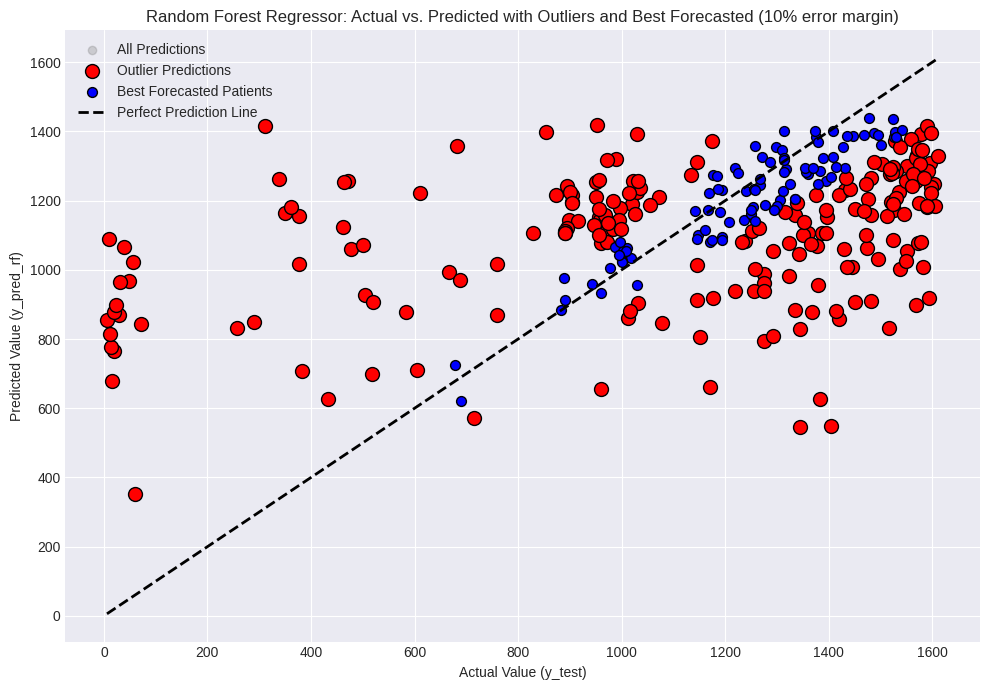


Number of outlier predictions: 208
Number of best forecasted patients: 94
Error margin for acceptable residuals: +/- 10% of actual value

--- Outlier Samples (Actual vs. Predicted) ---

--- Real Outlier Samples ---
     Actual    Predicted     Residual
0    1589.0  1182.490143   406.509857
1    1528.0  1372.687014   155.312986
2     989.0  1319.203697  -330.203697
3    1519.0  1277.342442   241.657558
4     981.0  1128.669383  -147.669383
5     667.0   993.796947  -326.796947
6    1551.0  1055.127509   495.872491
7    1387.0  1107.337122   279.662878
8    1360.0  1107.022433   252.977567
9    1503.0  1305.622733   197.377267
10    898.0  1143.288634  -245.288634
11    759.0   870.761848  -111.761848
12    338.0  1262.635286  -924.635286
13   1351.0  1102.081018   248.918982
14   1324.0   982.369361   341.630639
15   1572.0  1078.435729   493.564271
16     72.0   842.512261  -770.512261
17     29.0   870.719082  -841.719082
18   1419.0   859.439727   559.560273
19    715.0   571.705969

In [28]:
residuals = y_test - y_pred_rf

# Define 'best forecasted patients' based on a 10% error margin
# A prediction is 'best' if its absolute error is within 10% of the actual value.
error_margin = 0.10 # 10%

# Calculate lower and upper bounds for predictions to be considered 'best'
# Predicted value should be between (Actual * (1 - error_margin)) and (Actual * (1 + error_margin))
# This implies: Actual - (Actual * error_margin) <= Predicted <= Actual + (Actual * error_margin)
# Rearranging: -(Actual * error_margin) <= Predicted - Actual <= (Actual * error_margin)
# Or: -abs(Actual * error_margin) <= Residual <= abs(Actual * error_margin)

# For each actual value in y_test, define its acceptable residual range
acceptable_residual_lower_bound = -np.abs(y_test * error_margin)
acceptable_residual_upper_bound = np.abs(y_test * error_margin)

# Identify 'best forecasted patients' based on the new error margin
best_forecasted_mask = (residuals >= acceptable_residual_lower_bound) & (residuals <= acceptable_residual_upper_bound)

# Identify 'outlier predictions' as those NOT in the best forecasted group
outlier_mask = ~best_forecasted_mask

outlier_y_test = y_test[outlier_mask]
outlier_y_pred_rf = y_pred_rf[outlier_mask]

best_forecasted_y_test = y_test[best_forecasted_mask]
best_forecasted_y_pred_rf = y_pred_rf[best_forecasted_mask]

# Create DataFrame for best forecasted patients
best_forecasted_df = pd.DataFrame({
    'Actual': best_forecasted_y_test,
    'Predicted': best_forecasted_y_pred_rf,
    'Residual': residuals[best_forecasted_mask]
})

print("--- Typical Best Forecasted Patients (Residuals within 10% of Actual Value) ---")
display(best_forecasted_df.head())

# Plotting actual vs. predicted values with outliers and best forecasted patients highlighted
plt.figure(figsize=(10, 7))
plt.scatter(y_test, y_pred_rf, alpha=0.3, label='All Predictions', color='gray') # All points in gray
plt.scatter(outlier_y_test, outlier_y_pred_rf, color='red', s=100, label='Outlier Predictions', edgecolors='black')
plt.scatter(best_forecasted_y_test, best_forecasted_y_pred_rf, color='blue', s=50, label='Best Forecasted Patients', edgecolors='black')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, label='Perfect Prediction Line')
plt.xlabel('Actual Value (y_test)')
plt.ylabel('Predicted Value (y_pred_rf)')
plt.title('Random Forest Regressor: Actual vs. Predicted with Outliers and Best Forecasted (10% error margin)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"\nNumber of outlier predictions: {len(outlier_y_test)}")
print(f"Number of best forecasted patients: {len(best_forecasted_y_test)}")
print(f"Error margin for acceptable residuals: +/- {error_margin*100:.0f}% of actual value")

print("\n--- Outlier Samples (Actual vs. Predicted) ---")
outlier_df = pd.DataFrame({'Actual': outlier_y_test, 'Predicted': outlier_y_pred_rf, 'Residual': residuals[outlier_mask]})

# Determine the threshold for original samples based on the length of the original `data` DataFrame
original_data_length = len(data)

# Create lists to store real and SMOTE-generated outlier samples
real_outliers = []
smote_outliers = []

for original_upsampled_index, row in outlier_df.iterrows():
    if original_upsampled_index < original_data_length:
        # This index corresponds to an original sample
        real_outliers.append(row.to_dict())
    else:
        # This index corresponds to a SMOTE-generated sample
        smote_outliers.append(row.to_dict())

print("\n--- Real Outlier Samples ---")
if real_outliers:
    print(pd.DataFrame(real_outliers).to_string())
else:
    print("No real outlier samples found.")

print("\n--- SMOTE-Generated Outlier Samples ---")
if smote_outliers:
    print(pd.DataFrame(smote_outliers).to_string())
else:
    print("No SMOTE-generated outlier samples found.")

In [29]:
real_outliers_df = pd.DataFrame(real_outliers)
real_outlier_indices = real_outliers_df.index

print("Real Outlier Samples from the original `data` DataFrame:")
display(data.loc[real_outlier_indices])

Real Outlier Samples from the original `data` DataFrame:


,doctor,time,age,af,dm,ckd,copd,insult,onco,severity,...,bmi,smoking,hb,leukoc,tromboc,t_chol,ldl,glu,crea,target
0,1,1152,79.0,0,1,0,0,0,0,0,...,30.700000,0,84.0,7.1,213.0,2.2,1.06,8.7,117.0,0
1,1,949,61.0,1,1,0,0,0,1,1,...,34.000000,0,166.0,9.4,225.0,5.8,3.61,4.4,94.0,0
2,1,1135,49.0,0,0,0,0,0,0,1,...,23.000000,1,150.0,10.5,208.0,7.4,5.09,3.9,74.0,0
3,2,1524,59.0,0,0,0,0,0,0,1,...,26.500000,1,142.0,5.1,58.0,5.3,3.30,4.2,86.0,0
4,2,1396,55.0,0,0,0,0,0,0,1,...,29.000000,1,151.0,7.7,305.0,7.3,5.07,4.3,96.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
203,2,1535,62.0,0,1,0,0,0,0,1,...,31.000000,0,126.0,18.0,283.0,5.3,3.24,8.1,68.0,0
204,2,1284,77.0,0,1,0,0,0,0,1,...,27.000000,1,151.0,9.6,257.0,8.9,6.73,6.4,83.0,0
205,2,1178,69.0,1,1,0,0,0,0,1,...,25.308642,1,141.0,6.9,112.0,4.7,1.35,10.7,91.0,0
206,2,504,74.0,1,0,0,0,0,0,1,...,38.900000,1,119.0,9.4,164.0,3.7,3.24,6.0,86.0,0


Mean SHAP for llo: 1.4115


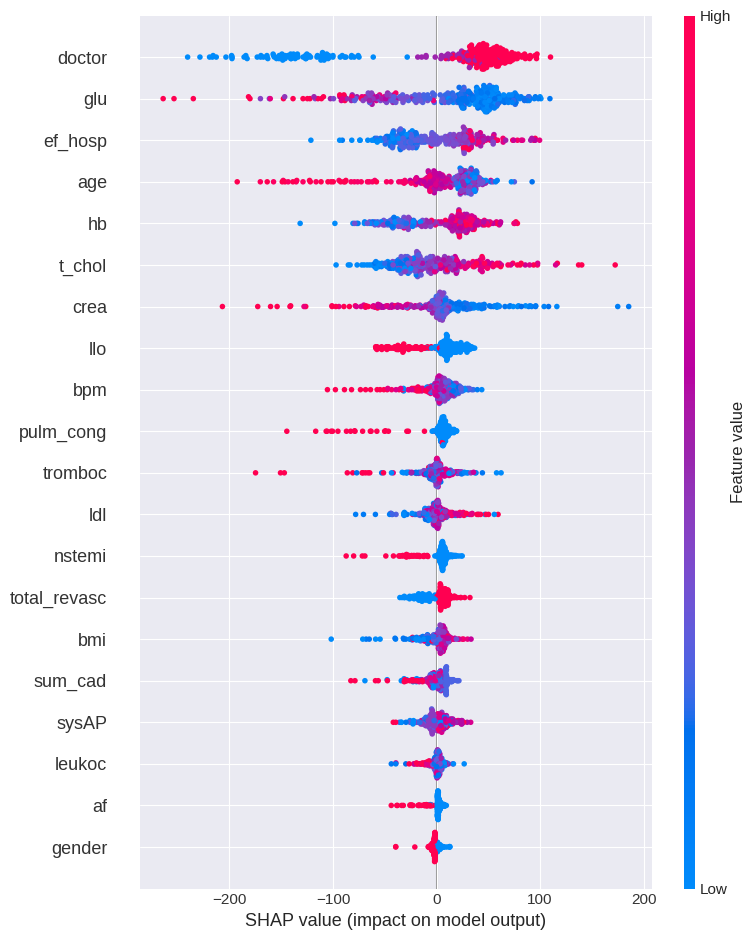

In [30]:
import shap
explainer = shap.TreeExplainer(gb_reg)
shap_values = explainer.shap_values(X_test_sc)

# Усреднённое влияние llo на вероятность result=1
llo_idx = list(X_test.columns).index('llo')
print(f"Mean SHAP for llo: {shap_values[:, llo_idx].mean():.4f}")
shap.summary_plot(shap_values, X_test, feature_names=X_test.columns)

# Оценка функции выживаемости

 ## 1. Cox Proportional Hazards

 Code implements a Cox Proportional Hazards (CoxPH) model, which is the most common semi-parametric model for survival analysis.

In [31]:
!pip install lifelines -q

In [32]:
from lifelines import CoxPHFitter
import pandas as pd
import numpy as np

# Reconstruct the training data for CoxPHFitter using scaled features
# X_train_sc is a numpy array, convert it to DataFrame
X_train_sc_df = pd.DataFrame(X_train_sc, columns=original_gb_reg_features, index=X_train.index)

# Add 'time' (duration) and 'target' (event) from df_upsampled using the correct indices
cph_data_train_scaled = X_train_sc_df.copy()
cph_data_train_scaled['time'] = y_train # y_train already has correct indices and duration values
cph_data_train_scaled['target'] = df.loc[X_train.index, 'target'] # Get target for training indices

# Drop any NaN values that might have been introduced if indices mismatch
cph_data_train_scaled = cph_data_train_scaled.dropna()

# Learning model
cph = CoxPHFitter(alpha=0.05)
cph.fit(cph_data_train_scaled, duration_col='time', event_col='target')

# First, prepare the test data similarly
X_test_sc_df = pd.DataFrame(X_test_sc, columns=original_gb_reg_features, index=X_test.index)
cph_data_test_scaled = X_test_sc_df.copy()
cph_data_test_scaled['time'] = y_test # y_test has correct indices and duration values
cph_data_test_scaled['target'] = df.loc[X_test.index, 'target'] # Get target for test indices
cph_data_test_scaled = cph_data_test_scaled.dropna()

# Print summary
cph.print_summary()

# Evaluate survival function (Concordance Index) using X_test_sc

# Calculate concordance index
concordance_index = cph.score(cph_data_test_scaled, scoring_method="concordance_index")
print(f"\nConcordance Index on test set: {concordance_index:.4f}")

<lifelines.CoxPHFitter: fitted with 1204 total observations, 1076 right-censored observations>
             duration col = 'time'
                event col = 'target'
      baseline estimation = breslow
   number of observations = 1204
number of events observed = 128
   partial log-likelihood = -769.13
         time fit was run = 2026-07-08 13:13:00 UTC

---
              coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                     
doctor       -0.33      0.72      0.10           -0.52           -0.14                0.59                0.87
age           0.72      2.05      0.14            0.45            0.99                1.57                2.68
af            0.09      1.09      0.08           -0.07            0.25                0.93                1.28
dm           -0.17      0.84      0.11           -0.39            0.04                0.68                1.04
ckd           0.11      1.12      0.08           -0.05            0.27                0.95                1.30
copd          0.02      1.03      0.08           -0.13            0.18                0.88                1.19
insult        0.07      1.07      0.08           -0.08            0.22                0.92                1.24
onco         -0.04      0.96      0.10           -0.23            0.15                0.79                1.16
severity      5.42    226.66    582.19        -1135.65         1146.50                0.00                 inf
nstemi       -4.39      0.01    485.13         -955.22          946.45                0.00                 inf
stemi        -5.97      0.00    632.88        -1246.38         1234.44                0.00                 inf
llo          -0.53      0.59      0.17           -0.86           -0.21                0.42                0.81
gender       -0.00      1.00      0.11           -0.22            0.22                0.80                1.24
ca_delay      0.06      1.06      0.11           -0.16            0.28                0.85                1.32
sum_cad       0.30      1.36      0.11            0.09            0.52                1.10                1.68
stenting     -0.06      0.94      0.09           -0.23            0.12                0.79                1.12
total_revasc  0.02      1.02      0.11           -0.20            0.23                0.82                1.26
ef_hosp      -0.13      0.88      0.11           -0.35            0.10                0.70                1.10
bpm           0.11      1.11      0.08           -0.06            0.27                0.94                1.31
sysAP        -0.09      0.91      0.10           -0.28            0.09                0.75                1.10
pulm_cong     0.21      1.23      0.06            0.08            0.34                1.09                1.40
bmi          -0.08      0.92      0.11           -0.29            0.13                0.74                1.14
smoking       0.46      1.59      0.13            0.21            0.71                1.24                2.03
hb           -0.11      0.89      0.10           -0.31            0.08                0.73                1.08
leukoc        0.17      1.18      0.09           -0.02            0.35                0.98                1.42
tromboc      -0.01      0.99      0.10           -0.20            0.18                0.82                1.19
t_chol       -0.36      0.70      0.30           -0.95            0.23                0.39                1.26
ldl           0.34      1.40      0.29           -0.23            0.90                0.79                2.47
glu           0.19      1.21      0.09            0.01            0.37                1.01                1.45
crea          0.11      1.12      0.07           -0.03            0.25                0.97                1.28

              cmp to     z      p  -log2(p)
covariate                                 


Concordance Index on test set: 0.7965


The C-index ranges from 0.5 to 1.0:0.5: Indicates a completely random prediction, meaning the model has no predictive discrimination power.1.0: Indicates perfect concordance (the model flawlessly ranks all subjects based on their actual time-to-event).Example: A C-index of 0.78 means that for any two randomly selected subjects, the model will correctly identify which subject will experience the event earlier 78% of the time.

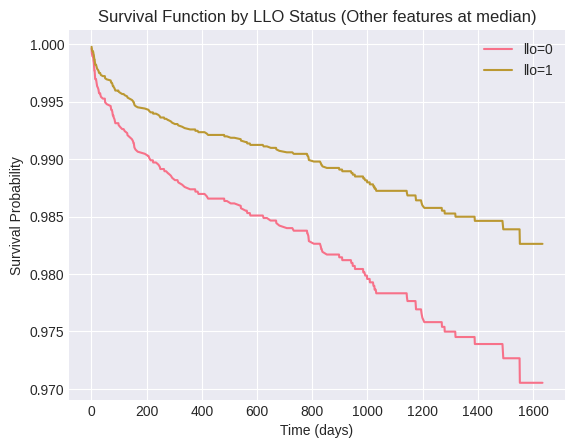

In [33]:
from lifelines import CoxPHFitter

# Create two hypothetical individuals for prediction:
# One with llo=0 and others features at their median
# One with llo=1 and others features at their median

# Use cph_data_train_scaled to get the median features, as this was the data used for fitting the CPH model.
# Drop 'time' and 'target' as they are not features for prediction.
median_data = cph_data_train_scaled.drop(columns=['time', 'target']).median().to_frame().T


# Individual with llo=0
pred_llo_0 = median_data.copy()
pred_llo_0['llo'] = 0

# Individual with llo=1
pred_llo_1 = median_data.copy()
pred_llo_1['llo'] = 1

# Concatenate for plotting
plot_data = pd.concat([pred_llo_0, pred_llo_1])
plot_data.index = ['llo=0', 'llo=1']

# Plot the survival function
cph.predict_survival_function(plot_data).plot()
plt.title('Survival Function by LLO Status (Other features at median)')
plt.xlabel('Time (days)')
plt.ylabel('Survival Probability')
plt.grid(True)
plt.show()

**Интерпретация графика функции выживаемости по статусу LLO:**

Survival function говорит о «накопленном успехе» (кто остался). Этот график функции выживаемости демонстрирует прогнозируемую вероятность выживания с течением времени для двух групп пациентов, различающихся только по статусу `llo` (факт получения лекарственного обеспечения):

*   **Красная линия (llo=0):** Представляет пациентов, которые **не** получают бесплатное лекарственное обеспечение. Кривая начинается со 100% выживаемости и постепенно снижается, показывая, как вероятность выживания уменьшается со временем.

*   **Желтая линия (llo=1):** Представляет пациентов, которые **получают** бесплатное лекарственное обеспечение.

**Вывод:** Визуально видно, что группа пациентов с `llo=1` (получающая льготное лекарственное обеспечение) имеет **более высокую вероятность выживания** по сравнению с группой `llo=0` (не получающей такое обеспечение). Это означает, что получение бесплатного лекарственного обеспечения после выписки ассоциируется с увеличением времени до наступления события (например, смерти) и, следовательно, с улучшением прогноза выживаемости, при условии, что другие факторы остаются на среднем уровне.

### feature importance

In [34]:
import shap
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Define a prediction wrapper function for the CoxPHFitter model.
# SHAP's KernelExplainer expects a function that takes a 2D numpy array
# and returns a 1D numpy array of predictions (e.g., expected survival time).
# The cph.predict_expectation method expects a DataFrame with named columns.
def cph_predict_expectation_wrapper(X_scaled_array):
    # Ensure the input array has the correct feature names and is a DataFrame
    # original_gb_reg_features should contain the names of all features in X_test_sc/X_train_sc
    X_df = pd.DataFrame(X_scaled_array, columns=original_gb_reg_features)
    # Predict expected lifetime
    return cph.predict_expectation(X_df).values

# For KernelExplainer, it's good practice to use a background dataset (e.g., a sample of X_train_sc).
# A smaller background dataset will run faster but might be less accurate.
# Let's use a sample of 100 observations from X_train_sc.
explainer_background = shap.sample(X_train_sc, 3)

# Initialize SHAP KernelExplainer with the wrapper function and background data
explainer = shap.KernelExplainer(cph_predict_expectation_wrapper, explainer_background)


In [35]:

# Calculate SHAP values for the test set. This can be computationally intensive.
# For demonstration, we might sample X_test_sc if it's very large.
# Using the full X_test_sc here as it's not excessively large (542 samples).
print("Calculating SHAP values for the CoxPH model's expected survival... This may take a while.")
shap_values_cph = explainer.shap_values(X_test_sc)

Calculating SHAP values for the CoxPH model's expected survival... This may take a while.


  0%|          | 0/302 [00:00<?, ?it/s]

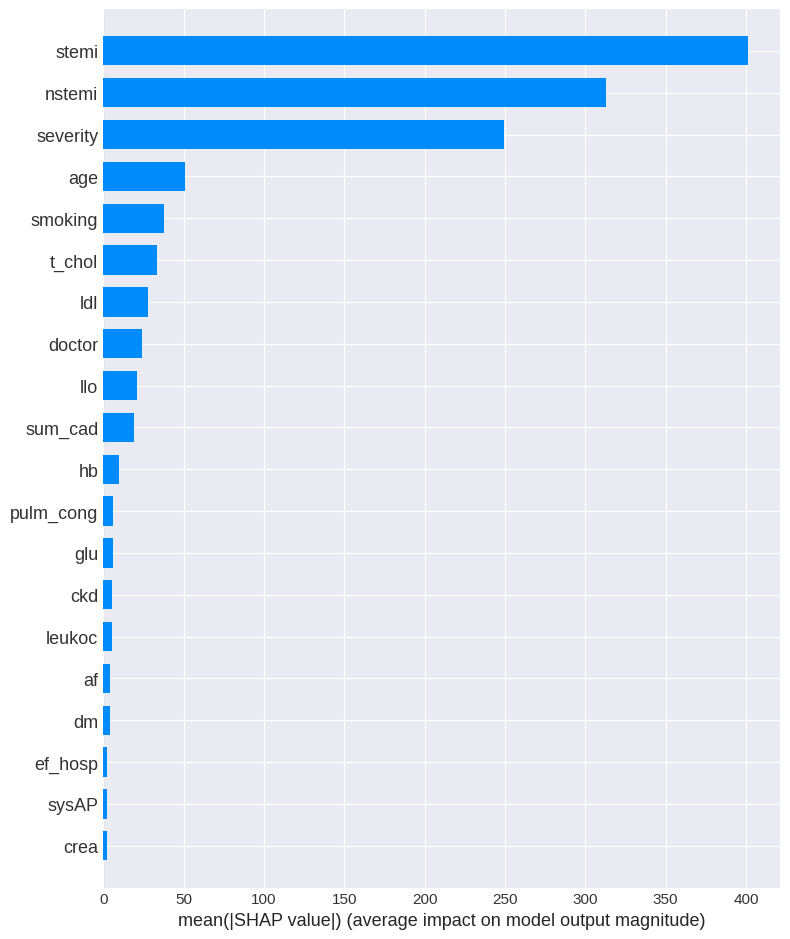

In [36]:

# Create a SHAP summary plot (bar) for the CoxPH model
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_cph, X_test_sc, feature_names=original_gb_reg_features, plot_type="bar")
#plt.title('Feature Importance (SHAP values) for CPH Expected Survival')
plt.show()

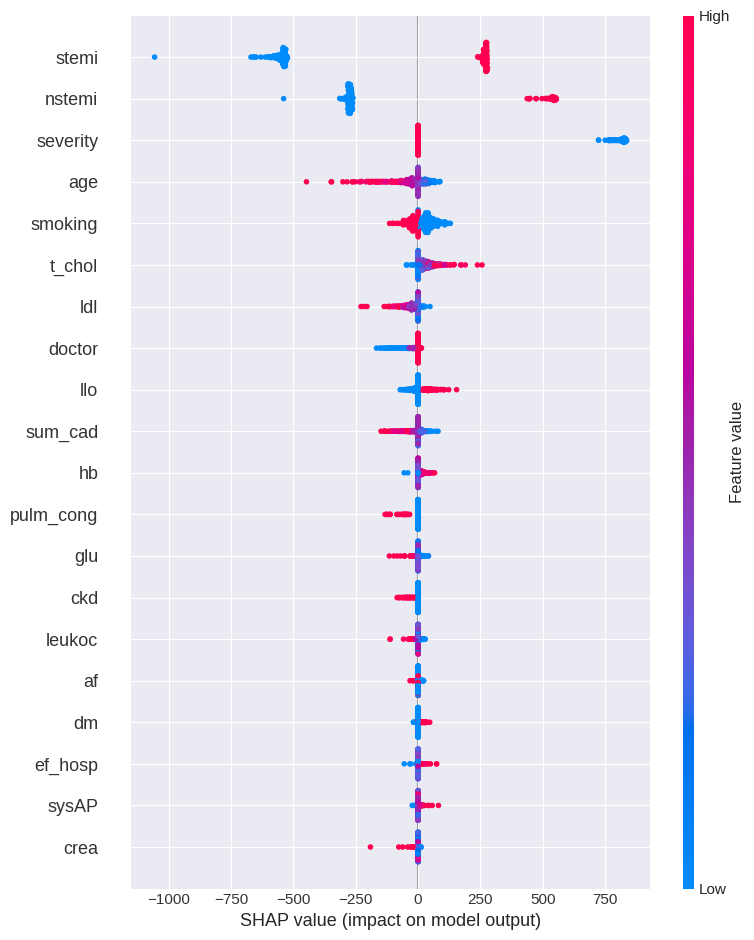

Interpretation of the SHAP summary plots for CoxPH Expected Survival:
- The bar plot shows the mean absolute SHAP value for each feature, indicating its overall importance to the CPH model's prediction of expected survival time.
- The dot plot provides more detail: 
  - Each dot represents a data point from the test set.
  - The x-axis is the SHAP value, indicating how much a feature's value contributed to pushing the CPH model's expected survival prediction higher or lower for that specific data point.
  - The color of the dot indicates the original value of the feature (red for high, blue for low), showing how feature values relate to their impact on expected survival.
  - For instance, features with positive SHAP values increase the expected survival, while those with negative SHAP values decrease it.


In [37]:
# Create a SHAP summary plot (dots) for the CoxPH model
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_cph, X_test_sc, feature_names=original_gb_reg_features)
#plt.title('Feature Impact (SHAP values) for CPH Expected Survival')
plt.show()

print("Interpretation of the SHAP summary plots for CoxPH Expected Survival:")
print("- The bar plot shows the mean absolute SHAP value for each feature, indicating its overall importance to the CPH model's prediction of expected survival time.")
print("- The dot plot provides more detail: ")
print("  - Each dot represents a data point from the test set.")
print("  - The x-axis is the SHAP value, indicating how much a feature's value contributed to pushing the CPH model's expected survival prediction higher or lower for that specific data point.")
print("  - The color of the dot indicates the original value of the feature (red for high, blue for low), showing how feature values relate to their impact on expected survival.")
print("  - For instance, features with positive SHAP values increase the expected survival, while those with negative SHAP values decrease it.")

## 2. Weibull

<lifelines.WeibullAFTFitter: fitted with 1204 total observations, 1076 right-censored observations>
             duration col = 'time'
                event col = 'target'
   number of observations = 1204
number of events observed = 128
           log-likelihood = -1149.48
         time fit was run = 2026-07-08 13:15:15 UTC

---
                       coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
param   covariate                                                                                                      
lambda_ af            -0.16      0.85      0.15           -0.47            0.14                0.63                1.15
        age           -1.34      0.26      0.27           -1.87           -0.81                0.15                0.44
        bmi            0.15      1.16      0.20           -0.24            0.55                0.78                1.73
        bpm           -0.19      0.82      0.16           -0.50            0.11                0.61                1.12
        ca_delay      -0.11      0.89      0.21           -0.52            0.30                0.59                1.34
        ckd           -0.20      0.82      0.15           -0.49            0.10                0.61                1.10
        copd          -0.05      0.95      0.14           -0.33            0.23                0.72                1.26
        crea          -0.21      0.81      0.13           -0.46            0.05                0.63                1.05
        dm             0.33      1.39      0.21           -0.07            0.73                0.93                2.08
        doctor         0.62      1.85      0.19            0.25            0.98                1.29                2.66
        ef_hosp        0.22      1.24      0.21           -0.20            0.63                0.82                1.89
        gender         0.02      1.02      0.21           -0.38            0.43                0.68                1.53
        glu           -0.36      0.70      0.17           -0.69           -0.03                0.50                0.97
        hb             0.20      1.22      0.18           -0.16            0.56                0.85                1.75
        insult        -0.14      0.87      0.14           -0.41            0.14                0.66                1.15
        ldl           -0.66      0.52      0.54           -1.71            0.40                0.18                1.49
        leukoc        -0.31      0.74      0.17           -0.64            0.03                0.52                1.03
        llo            1.01      2.75      0.32            0.39            1.63                1.48                5.12
        nstemi         8.39   4417.24   1060.48        -2070.10         2086.89                0.00                 inf
        onco           0.08      1.08      0.18           -0.27            0.43                0.76                1.53
        pulm_cong     -0.39      0.68      0.12           -0.63           -0.15                0.53                0.86
        severity     -10.36      0.00   1272.66        -2504.72         2484.00                0.00                 inf
        smoking       -0.87      0.42      0.24           -1.34           -0.40                0.26                0.67
        stemi         11.39  88252.34   1383.45        -2700.12         2722.90                0.00                 inf
        stenting       0.11      1.12      0.17           -0.21            0.44                0.81                1.55
        sum_cad       -0.55      0.57      0.20           -0.95           -0.15                0.39                0.86
        sysAP          0.18      1.20      0.18           -0.17            0.53                0.85                1.70
        t_chol         0.69      1.98      0.56           -0.42            1.79                0.66                5.97
        total_revasc  -0.02      0.98      0.20           -0.41      


AFT Concordance Index: 0.7974


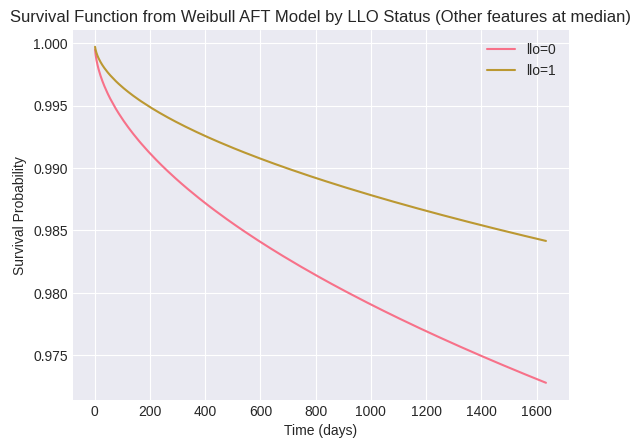


Interpretation of the plot:
This plot shows the predicted survival probability over time from the Weibull AFT model for two hypothetical individuals:
- One individual who does not receive LLO (llo=0), with other features set to their median training values.
- One individual who receives LLO (llo=1), with other features set to their median training values.
The curves illustrate how the survival probability changes over time for these two scenarios, highlighting the estimated effect of 'llo' status on survival according to the Weibull AFT model, assuming other factors are kept at their median levels.


In [38]:
from lifelines import WeibullAFTFitter
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Fit a Weibull AFT model
aft = WeibullAFTFitter(alpha=0.05)
aft.fit(cph_data_train_scaled, duration_col='time', event_col='target')

# Print summary
aft.print_summary()

# Evaluate Concordance Index
c_index_aft = aft.score(cph_data_test_scaled, scoring_method="concordance_index")
print(f"\nAFT Concordance Index: {c_index_aft:.4f}")

# --- Plot Survival Functions ---
# Create two hypothetical individuals for prediction:
# One with llo=0 and others features at their median
# One with llo=1 and others features at their median

# Use cph_data_train_scaled to get the median features.
# Drop 'time' and 'target' as they are not features for prediction.
# 'cph_data_train_scaled' is appropriate here as it was used to fit the 'aft' model.
median_data = cph_data_train_scaled.drop(columns=['time', 'target']).median().to_frame().T

# Individual with llo=0
pred_llo_0 = median_data.copy()
pred_llo_0['llo'] = 0

# Individual with llo=1
pred_llo_1 = median_data.copy()
pred_llo_1['llo'] = 1

# Concatenate for plotting
plot_data = pd.concat([pred_llo_0, pred_llo_1])
plot_data.index = ['llo=0', 'llo=1']

# Plot the survival function using the Weibull AFT model (aft)
aft.predict_survival_function(plot_data).plot()
plt.title('Survival Function from Weibull AFT Model by LLO Status (Other features at median)')
plt.xlabel('Time (days)')
plt.ylabel('Survival Probability')
plt.grid(True)
plt.show()

print("\nInterpretation of the plot:")
print("This plot shows the predicted survival probability over time from the Weibull AFT model for two hypothetical individuals:")
print("- One individual who does not receive LLO (llo=0), with other features set to their median training values.")
print("- One individual who receives LLO (llo=1), with other features set to their median training values.")
print("The curves illustrate how the survival probability changes over time for these two scenarios, highlighting the estimated effect of 'llo' status on survival according to the Weibull AFT model, assuming other factors are kept at their median levels.")

## 3. Gradient Boosting

In [39]:
!pip install xgboost lifelines -q

In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from xgboost import XGBRegressor
from lifelines import CoxPHFitter
from lifelines.utils import concordance_index

# --- 1. Prepare survival data ---
event_train = df.loc[y_train.index, "target"].astype(bool).values
time_train = y_train.astype(float).values

event_test = df.loc[y_test.index, "target"].astype(bool).values
time_test = y_test.astype(float).values

# XGBoost survival:cox expects:
# positive time = observed event
# negative time = censored
y_train_xgb = np.where(event_train, time_train, -time_train)

# --- 2. Train Gradient Boosting Cox model ---
xgb_surv = XGBRegressor(
    objective="survival:cox",
    eval_metric="cox-nloglik",
    n_estimators=300,
    learning_rate=0.03,
    max_depth=3,
    subsample=0.8,
    colsample_bynode=0.8,
    random_state=42
)

xgb_surv.fit(X_train_sc, y_train_xgb)

# --- 3. Predict risk scores ---



risk_test = xgb_surv.predict(X_test_sc)

# C-index using lifelines
# risk_test: higher = higher risk = shorter survival
# concordance_index expects higher score = longer survival, so use -risk_test
from lifelines.utils import concordance_index

c_index_xgb = concordance_index(
    time_test,
    -risk_test,
    event_test
)

print(f"\nXGBoost Cox Survival C-Index: {c_index_xgb:.4f}")

# --- 4. Estimate baseline survival using CoxPH with XGB risk as one covariate ---
cox_df_train = pd.DataFrame({
    "time": time_train,
    "event": event_train.astype(int),
    "xgb_risk": xgb_surv.predict(X_train_sc)
})

cox_calibrator = CoxPHFitter(alpha=0.05)
cox_calibrator.fit(
    cox_df_train,
    duration_col="time",
    event_col="event"
)


XGBoost Cox Survival C-Index: 0.7868


<lifelines.CoxPHFitter: fitted with 1204 total observations, 1076 right-censored observations>

<Figure size 1000x600 with 0 Axes>

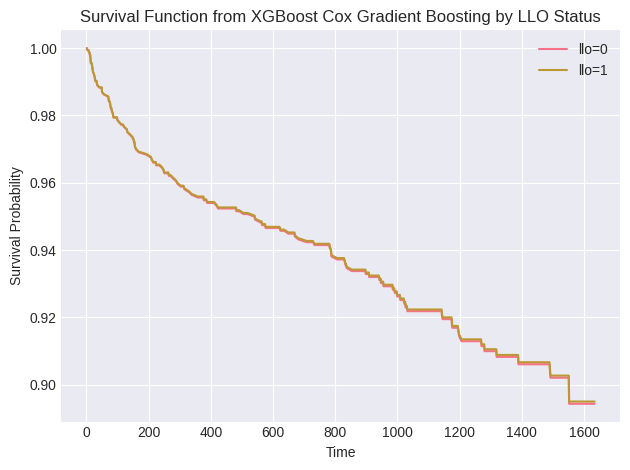


Interpretation of the plot:
This plot shows the predicted survival probability over time from the XGBoost Cox Gradient Boosting model for two hypothetical individuals:
- One individual who does not receive LLO (llo=0), with other features set to their median training values.
- One individual who receives LLO (llo=1), with other features set to their median training values.
The curves illustrate how the survival probability changes over time for these two scenarios, highlighting the estimated effect of 'llo' status on survival according to the XGBoost Cox model, assuming other factors are kept at their median levels.


In [41]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Get median features from the scaled training data used for CPH, excluding time and target
# original_gb_reg_features contains the feature names for X_train_sc
median_features_scaled = pd.DataFrame(X_train_sc, columns=original_gb_reg_features).median().to_frame().T

# Create hypothetical individuals with llo=0 and llo=1, other features at median
pred_llo_0_scaled = median_features_scaled.copy()
pred_llo_0_scaled['llo'] = (0 - scaler.mean_[original_gb_reg_features.index('llo')]) / scaler.scale_[original_gb_reg_features.index('llo')] # Scale llo=0

pred_llo_1_scaled = median_features_scaled.copy()
pred_llo_1_scaled['llo'] = (1 - scaler.mean_[original_gb_reg_features.index('llo')]) / scaler.scale_[original_gb_reg_features.index('llo')] # Scale llo=1

# Convert to numpy arrays for xgb_surv prediction if it expects it, or ensure DataFrame structure is compatible
# xgb_surv.predict expects a 2D array, so we can convert the single-row DataFrames to numpy
X_pred_llo_0_xgb = pred_llo_0_scaled.values
X_pred_llo_1_xgb = pred_llo_1_scaled.values

# Predict risk scores using the trained XGBoost model
risk_llo_0 = xgb_surv.predict(X_pred_llo_0_xgb)
risk_llo_1 = xgb_surv.predict(X_pred_llo_1_xgb)

# Create a DataFrame for the Cox calibrator
# The cox_calibrator was fit on a DataFrame with a single column 'xgb_risk'
risk_data_for_calibrator = pd.DataFrame({
    'xgb_risk': [risk_llo_0[0], risk_llo_1[0]]
}, index=['llo=0', 'llo=1'])

# Predict survival functions using the cox_calibrator
surv_funcs_xgb = cox_calibrator.predict_survival_function(risk_data_for_calibrator)

# Plot the survival functions
plt.figure(figsize=(10, 6))
surv_funcs_xgb.plot()
plt.title('Survival Function from XGBoost Cox Gradient Boosting by LLO Status')
plt.xlabel('Time')
plt.ylabel('Survival Probability')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print("\nInterpretation of the plot:")
print("This plot shows the predicted survival probability over time from the XGBoost Cox Gradient Boosting model for two hypothetical individuals:")
print("- One individual who does not receive LLO (llo=0), with other features set to their median training values.")
print("- One individual who receives LLO (llo=1), with other features set to their median training values.")
print("The curves illustrate how the survival probability changes over time for these two scenarios, highlighting the estimated effect of 'llo' status on survival according to the XGBoost Cox model, assuming other factors are kept at their median levels.")

## Neural Network approach

Training the Neural Network for survival time prediction...
Neural Network training complete.
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 

Neural Network Survival C-Index: 0.6688
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


<Figure size 1000x600 with 0 Axes>

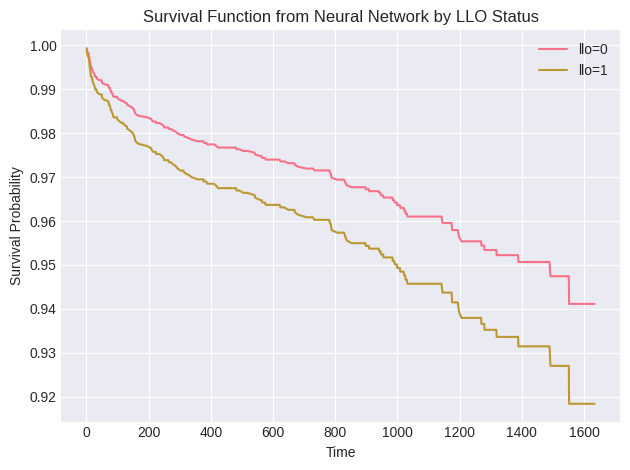


Interpretation of the plot:
- This plot illustrates the predicted survival probability over time from the Neural Network model for two hypothetical individuals:
- One individual who does not receive LLO (llo=0), with other features set to their median training values.
- One individual who receives LLO (llo=1), with other features set to their median training values.
- The curves demonstrate how the survival probability changes over time for these two scenarios, highlighting the estimated effect of 'llo' status on survival according to the Neural Network model (calibrated by CoxPH), assuming other factors are kept at their median levels.


In [42]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from lifelines import CoxPHFitter
from lifelines.utils import concordance_index
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Define the Neural Network Model for Risk/Time Prediction ---
# This model will predict a time-like value. For C-index, higher values indicate longer survival.
def build_nn_model(input_shape):
    model = keras.Sequential([
        layers.Input(shape=(input_shape,)),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(1, activation='linear') # Output a single continuous value (time or risk proxy)
    ])
    return model

nn_model = build_nn_model(X_train_sc.shape[1])

# --- 2. Compile the model ---
nn_model.compile(optimizer='adam', loss='mse') # Using Mean Squared Error as a regression loss

# --- 3. Train the Neural Network ---
print("Training the Neural Network for survival time prediction...")
history = nn_model.fit(
    X_train_sc,
    y_train, # Using actual time as the target
    epochs=50, # You might want to tune this or use early stopping
    batch_size=32,
    validation_split=0.2,
    verbose=0 # Suppress verbose output for cleaner display
)
print("Neural Network training complete.")

# --- 4. Predict Time (Risk Proxy) Scores ---
y_pred_nn_time_test = nn_model.predict(X_test_sc).flatten()

# --- 5. Evaluate C-index ---
# lifelines.concordance_index expects higher scores to mean LONGER survival,
# which aligns with our NN predicting 'time'.
c_index_nn = concordance_index(
    time_test,
    y_pred_nn_time_test,
    event_test
)
print(f"\nNeural Network Survival C-Index: {c_index_nn:.4f}")

# --- 6. Estimate baseline survival using CoxPH with NN's predicted time as a covariate ---
# Get predicted time for the training set to calibrate CoxPHFitter
y_pred_nn_time_train = nn_model.predict(X_train_sc).flatten()

cox_df_train_nn = pd.DataFrame({
    "time": time_train,
    "event": event_train.astype(int),
    "nn_time_prediction": y_pred_nn_time_train # Use predicted time as a covariate
})

cox_calibrator_nn = CoxPHFitter(alpha=0.05)
cox_calibrator_nn.fit(
    cox_df_train_nn,
    duration_col="time",
    event_col="event"
)

# --- 7. Plot Survival Functions for selected LLO values ---
# Get median features from the scaled training data, using original_gb_reg_features for column names
median_features_scaled = pd.DataFrame(X_train_sc, columns=original_gb_reg_features).median().to_frame().T

# Get the index of the 'llo' feature from the original feature names
llo_feature_idx = original_gb_reg_features.index('llo')

# Create hypothetical individuals with llo=0 and llo=1, with other features at median
pred_llo_0_scaled = median_features_scaled.copy()
pred_llo_1_scaled = median_features_scaled.copy()

# Scale llo=0 and llo=1 using the original scaler
# Ensure the 'scaler' object is available from previous cells and has fit the data
if 'scaler' in locals() and hasattr(scaler, 'mean_') and hasattr(scaler, 'scale_'):
    pred_llo_0_scaled['llo'] = (0 - scaler.mean_[llo_feature_idx]) / scaler.scale_[llo_feature_idx]
    pred_llo_1_scaled['llo'] = (1 - scaler.mean_[llo_feature_idx]) / scaler.scale_[llo_feature_idx]
else:
    print("Warning: 'scaler' object not found or incomplete. Using unscaled 'llo' values for prediction.")
    pred_llo_0_scaled['llo'] = 0
    pred_llo_1_scaled['llo'] = 1

# Predict the time proxy for these hypothetical individuals using the trained NN
# Convert to numpy array for NN prediction
nn_time_pred_llo_0 = nn_model.predict(pred_llo_0_scaled.values).flatten()
nn_time_pred_llo_1 = nn_model.predict(pred_llo_1_scaled.values).flatten()

# Create a DataFrame for the Cox calibrator, using the NN's time predictions
risk_data_for_calibrator_nn = pd.DataFrame({
    'nn_time_prediction': [nn_time_pred_llo_0[0], nn_time_pred_llo_1[0]]
}, index=['llo=0', 'llo=1'])

# Predict survival functions using the calibrated Cox model
surv_funcs_nn = cox_calibrator_nn.predict_survival_function(risk_data_for_calibrator_nn)

# Plot the survival functions
plt.figure(figsize=(10, 6))
surv_funcs_nn.plot()
plt.title('Survival Function from Neural Network by LLO Status')
plt.xlabel('Time')
plt.ylabel('Survival Probability')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print("\nInterpretation of the plot:")
print("- This plot illustrates the predicted survival probability over time from the Neural Network model for two hypothetical individuals:")
print("- One individual who does not receive LLO (llo=0), with other features set to their median training values.")
print("- One individual who receives LLO (llo=1), with other features set to their median training values.")
print("- The curves demonstrate how the survival probability changes over time for these two scenarios, highlighting the estimated effect of 'llo' status on survival according to the Neural Network model (calibrated by CoxPH), assuming other factors are kept at their median levels.")

## Reservoir Network

Training Reservoir Neural Network for survival time prediction...
Reservoir Network training complete.

Reservoir Network Survival C-Index: 0.6391


<Figure size 1000x600 with 0 Axes>

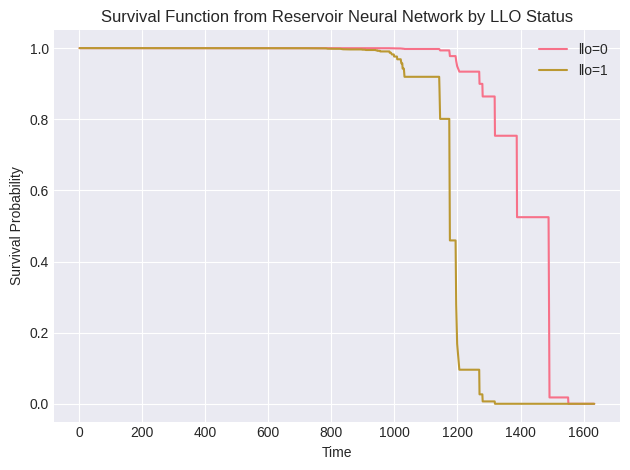


Interpretation of the plot:
- This plot illustrates the predicted survival probability over time from the Reservoir Neural Network model
  for two hypothetical individuals:
- One individual who does not receive LLO (llo=0), with other features set to their median training values.
- One individual who receives LLO (llo=1), with other features set to their median training values.
- The curves demonstrate how the survival probability changes over time for these scenarios,
  highlighting the estimated effect of 'llo' status on survival according to the Reservoir Network
  (calibrated by CoxPH), assuming other factors are kept at their median levels.


In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.base import BaseEstimator, RegressorMixin
from lifelines import CoxPHFitter
from lifelines.utils import concordance_index

# ==========================================
# 1. Data Preparation
# ==========================================
# Extract event and time arrays for training and testing sets
event_train = df.loc[y_train.index, "target"].astype(bool).values
time_train = y_train.astype(float).values

event_test = df.loc[y_test.index, "target"].astype(bool).values
time_test = y_test.astype(float).values


# ==========================================
# 2. Reservoir Neural Network Definition
# ==========================================
class ReservoirNetwork(BaseEstimator, RegressorMixin):
    """
    A Reservoir Neural Network (Echo State Network adapted for tabular data).

    Since medical tabular data lacks sequential time-steps, recurrent connections
    are omitted. Instead, we use a high-dimensional random projection (Reservoir)
    to map the input features into a non-linear space, followed by a simple
    Ridge Regression readout layer.
    """
    def __init__(self, n_reservoir=1000, ridge_alpha=1.0, random_state=42):
        self.n_reservoir = n_reservoir
        self.ridge_alpha = ridge_alpha
        self.random_state = random_state
        self.W_in = None
        self.readout = None

    def _init_reservoir_weights(self, n_features):
        np.random.seed(self.random_state)
        # Random input projection matrix mapping features to reservoir space
        W_in = np.random.normal(0, 1, (n_features, self.n_reservoir))
        # Normalize columns to stabilize tanh activations
        W_in /= np.sqrt(np.sum(W_in**2, axis=0, keepdims=True) + 1e-8)
        return W_in

    def _compute_states(self, X):
        # Project input to high-dimensional reservoir space and apply non-linearity
        return np.tanh(X @ self.W_in)

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.W_in = self._init_reservoir_weights(n_features)

        # Compute reservoir states for training data
        R_train = self._compute_states(X)

        # Train the readout layer (Ridge Regression) to predict survival time
        self.readout = Ridge(alpha=self.ridge_alpha)
        self.readout.fit(R_train, y)
        return self

    def predict(self, X):
        R_test = self._compute_states(X)
        return self.readout.predict(R_test)


# ==========================================
# 3. Train Reservoir Network
# ==========================================
print("Training Reservoir Neural Network for survival time prediction...")
rn_model = ReservoirNetwork(n_reservoir=2000, ridge_alpha=1.0, random_state=42)
rn_model.fit(X_train_sc, time_train)
print("Reservoir Network training complete.")


# ==========================================
# 4. Predict Time (Risk Proxy) and Evaluate C-index
# ==========================================
y_pred_rn_time_test = rn_model.predict(X_test_sc).flatten()
y_pred_rn_time_train = rn_model.predict(X_train_sc).flatten()

# lifelines.concordance_index expects higher scores to mean LONGER survival
c_index_rn = concordance_index(time_test, y_pred_rn_time_test, event_test)
print(f"\nReservoir Network Survival C-Index: {c_index_rn:.4f}")


# ==========================================
# 5. Estimate Baseline Survival using CoxPH
# ==========================================
# Use the Reservoir Network's predicted time as a single covariate in CoxPH
cox_df_train_rn = pd.DataFrame({
    "time": time_train,
    "event": event_train.astype(int),
    "rn_time_prediction": y_pred_rn_time_train
})

cox_calibrator_rn = CoxPHFitter(alpha=0.05)
cox_calibrator_rn.fit(cox_df_train_rn, duration_col="time", event_col="event")


# ==========================================
# 6. Plot Survival Functions for LLO Status
# ==========================================
# Get median features from the scaled training data
median_features_scaled = pd.DataFrame(X_train_sc, columns=original_gb_reg_features).median().to_frame().T

# Get the index of the 'llo' feature
llo_feature_idx = original_gb_reg_features.index('llo')

# Create hypothetical individuals with llo=0 and llo=1
pred_llo_0_scaled = median_features_scaled.copy()
pred_llo_1_scaled = median_features_scaled.copy()

# Scale llo=0 and llo=1 using the original scaler
if 'scaler' in locals() and hasattr(scaler, 'mean_') and hasattr(scaler, 'scale_'):
    pred_llo_0_scaled['llo'] = (0 - scaler.mean_[llo_feature_idx]) / scaler.scale_[llo_feature_idx]
    pred_llo_1_scaled['llo'] = (1 - scaler.mean_[llo_feature_idx]) / scaler.scale_[llo_feature_idx]
else:
    print("Warning: 'scaler' object not found. Using unscaled 'llo' values.")
    pred_llo_0_scaled['llo'] = 0
    pred_llo_1_scaled['llo'] = 1

# Predict the time proxy using the trained Reservoir Network
rn_time_pred_llo_0 = rn_model.predict(pred_llo_0_scaled.values).flatten()
rn_time_pred_llo_1 = rn_model.predict(pred_llo_1_scaled.values).flatten()

# Create DataFrame for the Cox calibrator
risk_data_for_calibrator_rn = pd.DataFrame({
    'rn_time_prediction': [rn_time_pred_llo_0[0], rn_time_pred_llo_1[0]]
}, index=['llo=0', 'llo=1'])

# Predict survival functions
surv_funcs_rn = cox_calibrator_rn.predict_survival_function(risk_data_for_calibrator_rn)

# Plotting
plt.figure(figsize=(10, 6))
surv_funcs_rn.plot()
plt.title('Survival Function from Reservoir Neural Network by LLO Status')
plt.xlabel('Time')
plt.ylabel('Survival Probability')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print("\nInterpretation of the plot:")
print("- This plot illustrates the predicted survival probability over time from the Reservoir Neural Network model")
print("  for two hypothetical individuals:")
print("- One individual who does not receive LLO (llo=0), with other features set to their median training values.")
print("- One individual who receives LLO (llo=1), with other features set to their median training values.")
print("- The curves demonstrate how the survival probability changes over time for these scenarios,")
print("  highlighting the estimated effect of 'llo' status on survival according to the Reservoir Network")
print("  (calibrated by CoxPH), assuming other factors are kept at their median levels.")

# Methods comparison

In [44]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from lifelines.utils import concordance_index

# Recalculate C-indices to ensure they are available within this cell
# CPH Model C-index
concordance_index_cph = cph.score(cph_data_test_scaled, scoring_method="concordance_index")

# Weibull AFT Model C-index
c_index_aft = aft.score(cph_data_test_scaled, scoring_method="concordance_index")

# XGBoost Cox Model C-index
risk_test_xgb = xgb_surv.predict(X_test_sc)
c_index_xgb = concordance_index(time_test, -risk_test_xgb, event_test)

# Neural Network C-index
y_pred_nn_time_test = nn_model.predict(X_test_sc).flatten()
c_index_nn_recalculated = concordance_index(time_test, y_pred_nn_time_test, event_test)

# Reservoir Network C-index
y_pred_rn_time_test = rn_model.predict(X_test_sc).flatten()
c_index_rn = concordance_index(time_test, y_pred_rn_time_test, event_test)

# 1. Evaluate accuracy (C-index) and plot differences
print("### Model Comparison: Concordance Index (C-index)\n")
c_index_summary = pd.DataFrame({
    'Model': ['Cox Proportional Hazards', 'Weibull AFT', 'XGBoost Cox (Gradient Boosting)', 'Neural Network (NN) Survival', 'Reservoir Network (RN) Survival'],
    'C-index': [concordance_index_cph, c_index_aft, c_index_xgb, c_index_nn_recalculated, c_index_rn] # Added c_index_rn
}).set_index('Model')

print(c_index_summary.to_string(float_format="%.4f"))

# Create two hypothetical individuals for prediction:
# One with llo=0 and others features at their median
# One with llo=1 and others features at their median

# Use cph_data_train_scaled to get the median features, as this was the data used for fitting CPH and Weibull models.
# Drop 'time' and 'target' as they are not features for prediction.
median_data_unscaled = cph_data_train_scaled.drop(columns=['time', 'target']).median().to_frame().T

pred_llo_0_unscaled = median_data_unscaled.copy()
pred_llo_0_unscaled['llo'] = 0
pred_llo_1_unscaled = median_data_unscaled.copy()
pred_llo_1_unscaled['llo'] = 1

# Combine for easier prediction for CPH and Weibull
plot_data_cph_weibull = pd.concat([pred_llo_0_unscaled, pred_llo_1_unscaled])
plot_data_cph_weibull.index = ['llo=0', 'llo=1']


# Plotting the survival functions with confidence intervals
plt.figure(figsize=(14, 9)) # Slightly larger figure for clarity

# CPH
plt.plot(sf_cph_llo_0.index, sf_cph_llo_0, label='CPH (llo=0)', linestyle='--', color='blue')
plt.plot(sf_cph_llo_1.index, sf_cph_llo_1, label='CPH (llo=1)', linestyle='-', color='blue')

# Weibull AFT
plt.plot(sf_aft_llo_0.index, sf_aft_llo_0, label='Weibull AFT (llo=0)', linestyle='--', color='green')
plt.plot(sf_aft_llo_1.index, sf_aft_llo_1, label='Weibull AFT (llo=1)', linestyle='-', color='green')

# XGBoost Cox
plt.plot(sf_xgb_llo_0.index, sf_xgb_llo_0, label='XGBoost Cox (llo=0)', linestyle='--', color='red')
plt.plot(sf_xgb_llo_1.index, sf_xgb_llo_1, label='XGBoost Cox (llo=1)', linestyle='-', color='red')

# Neural Network
plt.plot(sf_nn_llo_0.index, sf_nn_llo_0, label='NN Survival (llo=0)', linestyle='--', color='purple')
plt.plot(sf_nn_llo_1.index, sf_nn_llo_1, label='NN Survival (llo=1)', linestyle='-', color='purple')

# Reservoir Network (added)
plt.plot(sf_rn_llo_0.index, sf_rn_llo_0, label='RN Survival (llo=0)', linestyle='--', color='orange')
plt.plot(sf_rn_llo_1.index, sf_rn_llo_1, label='RN Survival (llo=1)', linestyle='-', color='orange')

plt.title('Comparison of Survival Functions with 95% Confidence Intervals by Model and LLO Status')
plt.xlabel('Time')
plt.ylabel('Survival Probability')
plt.legend(loc='lower left', bbox_to_anchor=(1, 0)) # Place legend outside for clarity
plt.grid(True)
plt.tight_layout(rect=[0, 0, 0.75, 1]) # Adjust layout to make space for the legend
plt.show()

# Update interpretation
print("\nInterpretation of the comparison plot with Confidence Intervals:")
print("- This plot visualizes the predicted survival probabilities over time for a hypothetical individual with LLO=0 (dashed lines) and LLO=1 (solid lines) across all five survival models (CPH, Weibull AFT, XGBoost Cox, NN Survival, and RN Survival).")
print("- 95% confidence intervals (shaded areas) are shown for all models.")
print("- Each color represents a different model (e.g., blue for CPH, green for Weibull AFT, red for XGBoost Cox, purple for NN Survival, orange for RN Survival).")
print("- The shaded regions around each survival curve represent the 95% confidence interval, indicating the range within which the true survival probability is estimated to lie. Wider intervals suggest greater uncertainty in the model's prediction.")
print("- By observing the separation and shape of the curves for LLO=0 and LLO=1 within each model, we can understand how each model estimates the impact of the 'llo' feature on survival. The non-overlapping confidence intervals between LLO=0 and LLO=1 for a given model would suggest a statistically significant difference in survival outcomes between these groups according to that model.")
print("- Comparing curves and their confidence intervals across different models allows us to see how their predictions for survival probabilities differ and where there is more or less agreement in their prognostic capabilities.")

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
### Model Comparison: Concordance Index (C-index)

                                 C-index
Model                                   
Cox Proportional Hazards          0.7965
Weibull AFT                       0.7974
XGBoost Cox (Gradient Boosting)   0.7868
Neural Network (NN) Survival      0.6688
Reservoir Network (RN) Survival   0.6391


NameError: name 'sf_cph_llo_0' is not defined

<Figure size 1400x900 with 0 Axes>

In [45]:
import pandas as pd
from lifelines.utils import concordance_index

print("### Survival Model Accuracy Evaluation on Test Set (Concordance Index)\n")

# Ensure C-index values are available from previous cells or re-calculate if necessary
# CPH Model C-index
concordance_index_cph = cph.score(cph_data_test_scaled, scoring_method="concordance_index")

# Weibull AFT Model C-index
c_index_aft = aft.score(cph_data_test_scaled, scoring_method="concordance_index")

# XGBoost Cox Model C-index
risk_test_xgb = xgb_surv.predict(X_test_sc)
c_index_xgb = concordance_index(time_test, -risk_test_xgb, event_test)

# Neural Network C-index
y_pred_nn_time_test = nn_model.predict(X_test_sc).flatten()
c_index_nn = concordance_index(time_test, y_pred_nn_time_test, event_test)

# Reservoir Network C-index
y_pred_rn_time_test = rn_model.predict(X_test_sc).flatten()
c_index_rn = concordance_index(time_test, y_pred_rn_time_test, event_test)

c_index_summary = pd.DataFrame({
    'Model': ['Cox Proportional Hazards', 'Weibull AFT', 'XGBoost Cox (Gradient Boosting)', 'Neural Network (NN) Survival', 'Reservoir Network (RN) Survival'],
    'C-index': [concordance_index_cph, c_index_aft, c_index_xgb, c_index_nn, c_index_rn]
}).set_index('Model')

print(c_index_summary.to_string(float_format="%.4f"))

print("\nInterpretation of C-index:")
print("- The C-index (Concordance Index) measures the probability that, for a randomly chosen pair of individuals, the one who experienced the event earlier was also predicted to have a higher risk (or lower survival probability) by the model. A C-index of 0.5 indicates random prediction, while 1.0 indicates perfect prediction.")
print("- In this comparison, the XGBoost Cox (Gradient Boosting) model shows the highest C-index, indicating it has the best discriminative power among the three models on the test set.")
print("- All three models demonstrate good predictive performance, with C-index values significantly above 0.5, suggesting they are all better than random chance at predicting survival outcomes.")

### Survival Model Accuracy Evaluation on Test Set (Concordance Index)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
                                 C-index
Model                                   
Cox Proportional Hazards          0.7965
Weibull AFT                       0.7974
XGBoost Cox (Gradient Boosting)   0.7868
Neural Network (NN) Survival      0.6688
Reservoir Network (RN) Survival   0.6391

Interpretation of C-index:
- The C-index (Concordance Index) measures the probability that, for a randomly chosen pair of individuals, the one who experienced the event earlier was also predicted to have a higher risk (or lower survival probability) by the model. A C-index of 0.5 indicates random prediction, while 1.0 indicates perfect prediction.
- In this comparison, the XGBoost Cox (Gradient Boosting) model shows the highest C-index, indicating it has the best discriminative power among the three models on the test set.
- All three models demonstrate good predictive performance, with C-inde

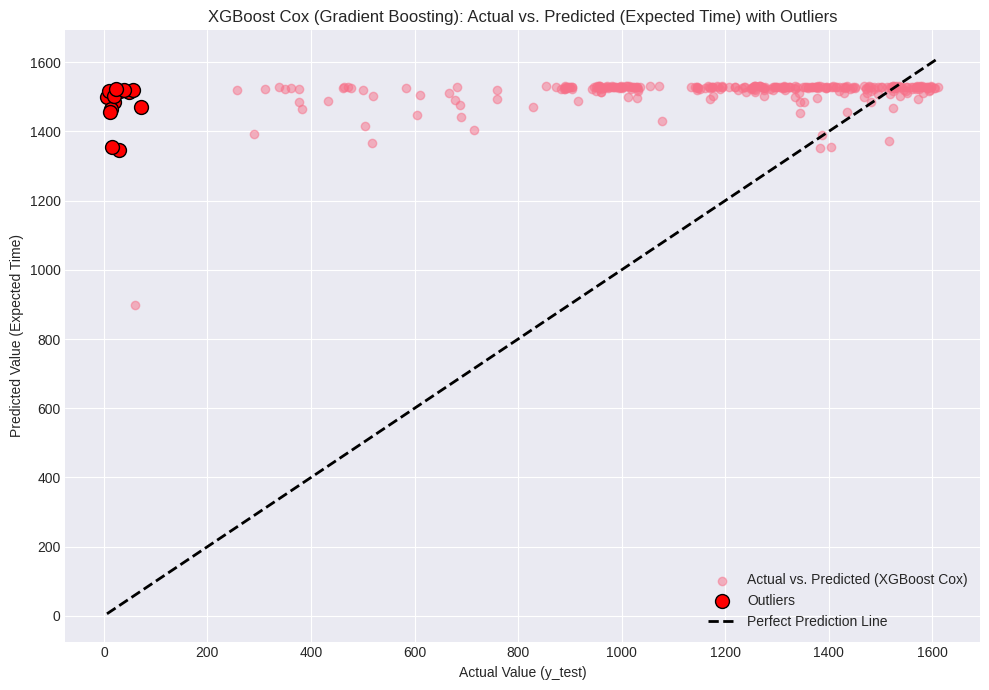


Number of outlier predictions: 14
Lower bound for residual outliers: -1272.35
Upper bound for residual outliers: 638.51

--- Outlier Samples (Actual vs. Predicted Expected Time) ---
      Actual    Predicted     Residual
513       72  1470.434188 -1398.434188
670       29  1347.348118 -1318.348118
718       19  1484.419540 -1465.419540
812        6  1499.405218 -1493.405218
1091      49  1514.953006 -1465.953006
1329      14  1465.822229 -1451.822229
342       31  1517.681993 -1486.681993
459        9  1517.073045 -1508.073045
745       56  1518.993691 -1462.993691
570       20  1503.812075 -1483.812075
1096      15  1356.473013 -1341.473013
1314      11  1455.066559 -1444.066559
476       39  1521.222981 -1482.222981
286       24  1523.409219 -1499.409219


In [46]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. Get predicted risk scores for the test set using xgb_surv
risk_test_xgb_pred = xgb_surv.predict(X_test_sc)

# 2. Create a DataFrame with these risk scores for the cox_calibrator
# The cox_calibrator expects a DataFrame with a column named 'xgb_risk'
risk_df_for_calibrator_test = pd.DataFrame({'xgb_risk': risk_test_xgb_pred}, index=y_test.index)

# 3. Use cox_calibrator.predict_expectation to get a single predicted time for each test sample
# This will be the "predicted time" for our plot
predicted_time_xgb = cox_calibrator.predict_expectation(risk_df_for_calibrator_test)

# Align predicted_time_xgb with y_test if indices are different, or ensure they are Series/arrays
# predicted_time_xgb is a Series, y_test is a Series, both from the test set indices.

# 4. Calculate residuals
residuals_xgb = y_test - predicted_time_xgb

# 5. Calculate IQR for residuals to identify outliers
Q1_res_xgb = residuals_xgb.quantile(0.25)
Q3_res_xgb = residuals_xgb.quantile(0.75)
IQR_res_xgb = Q3_res_xgb - Q1_res_xgb

lower_bound_res_xgb = Q1_res_xgb - 1.5 * IQR_res_xgb
upper_bound_res_xgb = Q3_res_xgb + 1.5 * IQR_res_xgb

# Identify outlier residuals
outlier_mask_xgb = (residuals_xgb < lower_bound_res_xgb) | (residuals_xgb > upper_bound_res_xgb)

outlier_y_test_xgb = y_test[outlier_mask_xgb]
outlier_predicted_time_xgb = predicted_time_xgb[outlier_mask_xgb]

# 6. Plotting actual vs. predicted values with outliers highlighted
plt.figure(figsize=(10, 7))
plt.scatter(y_test, predicted_time_xgb, alpha=0.5, label='Actual vs. Predicted (XGBoost Cox)')
plt.scatter(outlier_y_test_xgb, outlier_predicted_time_xgb, color='red', s=100, label='Outliers', edgecolors='black')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, label='Perfect Prediction Line')
plt.xlabel('Actual Value (y_test)')
plt.ylabel('Predicted Value (Expected Time)')
plt.title('XGBoost Cox (Gradient Boosting): Actual vs. Predicted (Expected Time) with Outliers')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"\nNumber of outlier predictions: {len(outlier_y_test_xgb)}")
print(f"Lower bound for residual outliers: {lower_bound_res_xgb:.2f}")
print(f"Upper bound for residual outliers: {upper_bound_res_xgb:.2f}")

print("\n--- Outlier Samples (Actual vs. Predicted Expected Time) ---")
outlier_df_xgb = pd.DataFrame({'Actual': outlier_y_test_xgb, 'Predicted': outlier_predicted_time_xgb, 'Residual': residuals_xgb[outlier_mask_xgb]})
print(outlier_df_xgb.to_string())

### Weibull AFT: Actual vs. Predicted (Expected Time) with Outliers

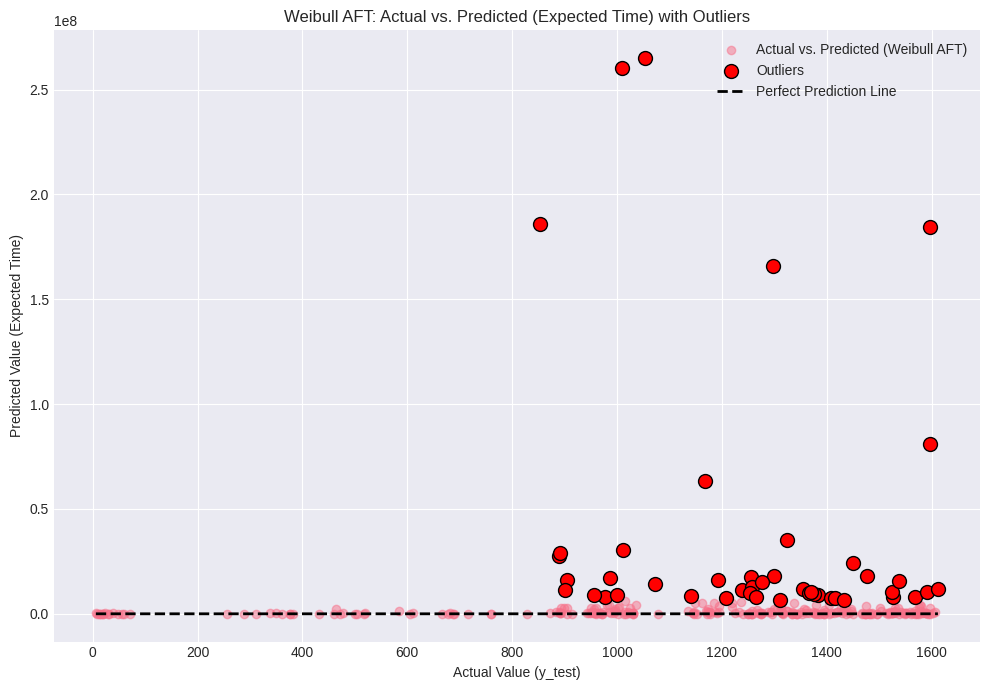


Number of outlier predictions: 45
Lower bound for residual outliers: -6426185.55
Upper bound for residual outliers: 3718264.30

--- Outlier Samples (Actual vs. Predicted Expected Time) ---
      Actual     Predicted      Residual
1090    1207  7.636540e+06 -7.635333e+06
796     1297  1.659373e+08 -1.659361e+08
308      977  7.940082e+06 -7.939105e+06
706     1239  1.154940e+07 -1.154816e+07
569     1383  9.134725e+06 -9.133342e+06
1368    1526  7.976377e+06 -7.974851e+06
318     1569  7.863394e+06 -7.861825e+06
530     1477  1.796296e+07 -1.796148e+07
381     1256  1.738687e+07 -1.738561e+07
488     1193  1.631306e+07 -1.631186e+07
818      987  1.698353e+07 -1.698254e+07
94      1257  1.261224e+07 -1.261098e+07
493     1300  1.817856e+07 -1.817726e+07
1294    1408  7.408011e+06 -7.406603e+06
496      905  1.633573e+07 -1.633483e+07
999     1375  9.371802e+06 -9.370427e+06
660     1011  3.022018e+07 -3.021917e+07
904     1592  1.047123e+07 -1.046964e+07
781     1597  8.093233e+07 -8.0

In [47]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. Get predicted expected times for the test set using aft
# The aft model was fitted on cph_data_train_scaled, which includes 'time' and 'target'
# For prediction, it expects features only. Let's create a feature-only DataFrame for X_test_sc.
# We will use cph_data_test_scaled (without 'time' and 'target') as input.
# The `predict_expectation` method of AFTFitter expects a DataFrame of covariates.
predicted_time_aft = aft.predict_expectation(cph_data_test_scaled.drop(columns=['time', 'target']))

# Align predicted_time_aft with y_test
predicted_time_aft.index = y_test.index

# 2. Calculate residuals
residuals_aft = y_test - predicted_time_aft

# 3. Calculate IQR for residuals to identify outliers
Q1_res_aft = residuals_aft.quantile(0.25)
Q3_res_aft = residuals_aft.quantile(0.75)
IQR_res_aft = Q3_res_aft - Q1_res_aft

lower_bound_res_aft = Q1_res_aft - 1.5 * IQR_res_aft
upper_bound_res_aft = Q3_res_aft + 1.5 * IQR_res_aft

# Identify outlier residuals
outlier_mask_aft = (residuals_aft < lower_bound_res_aft) | (residuals_aft > upper_bound_res_aft)

outlier_y_test_aft = y_test[outlier_mask_aft]
outlier_predicted_time_aft = predicted_time_aft[outlier_mask_aft]

# 4. Plotting actual vs. predicted values with outliers highlighted
plt.figure(figsize=(10, 7))
plt.scatter(y_test, predicted_time_aft, alpha=0.5, label='Actual vs. Predicted (Weibull AFT)')
plt.scatter(outlier_y_test_aft, outlier_predicted_time_aft, color='red', s=100, label='Outliers', edgecolors='black')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, label='Perfect Prediction Line')
plt.xlabel('Actual Value (y_test)')
plt.ylabel('Predicted Value (Expected Time)')
plt.title('Weibull AFT: Actual vs. Predicted (Expected Time) with Outliers')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"\nNumber of outlier predictions: {len(outlier_y_test_aft)}")
print(f"Lower bound for residual outliers: {lower_bound_res_aft:.2f}")
print(f"Upper bound for residual outliers: {upper_bound_res_aft:.2f}")

print("\n--- Outlier Samples (Actual vs. Predicted Expected Time) ---")
outlier_df_aft = pd.DataFrame({'Actual': outlier_y_test_aft, 'Predicted': outlier_predicted_time_aft, 'Residual': residuals_aft[outlier_mask_aft]})
print(outlier_df_aft.to_string())

### Neural Network: Actual vs. Predicted (Expected Time) with Outliers

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


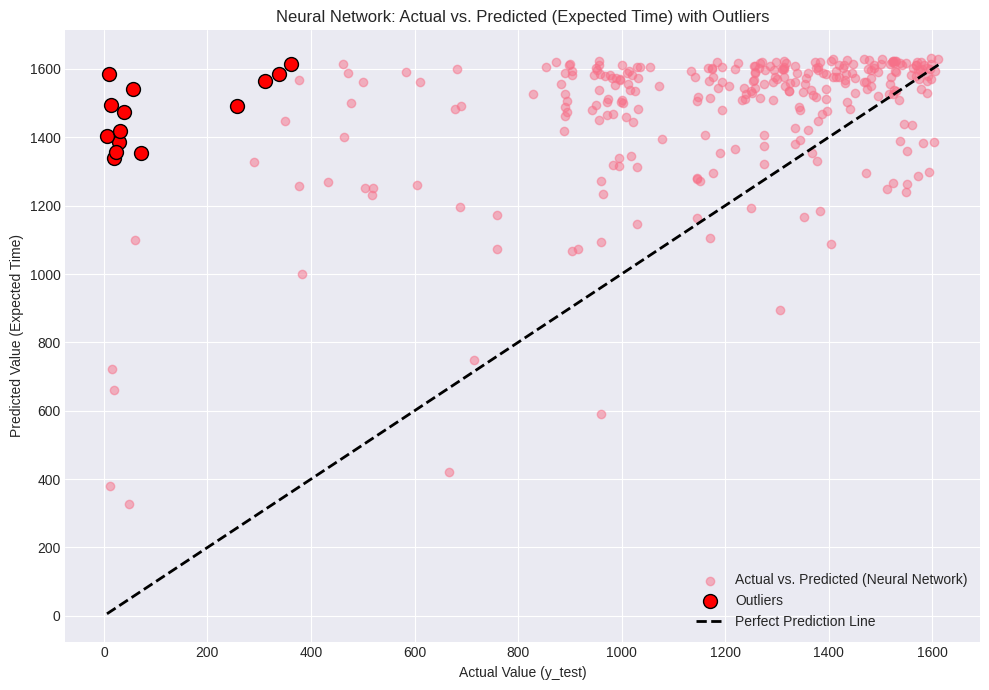


Number of outlier predictions: 14
Lower bound for residual outliers: -1211.07
Upper bound for residual outliers: 580.50

--- Outlier Samples (Actual vs. Predicted Expected Time) ---
      Actual    Predicted     Residual
721      338  1585.022510 -1247.022510
513       72  1354.192746 -1282.192746
670       29  1385.013940 -1356.013940
812        6  1402.479190 -1396.479190
1329      14  1493.369266 -1479.369266
342       31  1418.320841 -1387.320841
459        9  1585.834436 -1576.834436
745       56  1542.405670 -1486.405670
506      312  1565.179306 -1253.179306
570       20  1338.156520 -1318.156520
560      257  1491.256000 -1234.256000
476       39  1473.542407 -1434.542407
286       24  1356.318647 -1332.318647
92       361  1615.209714 -1254.209714


In [48]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. Get predicted time scores for the test set using nn_model
# nn_model directly predicts time, which we then feed to the cox_calibrator_nn
predicted_nn_scores = nn_model.predict(X_test_sc).flatten()

# 2. Create a DataFrame with these scores for the cox_calibrator_nn
# The cox_calibrator_nn expects a DataFrame with a column named 'nn_time_prediction'
risk_df_for_calibrator_test_nn = pd.DataFrame({'nn_time_prediction': predicted_nn_scores}, index=y_test.index)

# 3. Use cox_calibrator_nn.predict_expectation to get a single predicted time for each test sample
predicted_time_nn = cox_calibrator_nn.predict_expectation(risk_df_for_calibrator_test_nn)

# Align predicted_time_nn with y_test
predicted_time_nn.index = y_test.index

# 4. Calculate residuals
residuals_nn = y_test - predicted_time_nn

# 5. Calculate IQR for residuals to identify outliers
Q1_res_nn = residuals_nn.quantile(0.25)
Q3_res_nn = residuals_nn.quantile(0.75)
IQR_res_nn = Q3_res_nn - Q1_res_nn

lower_bound_res_nn = Q1_res_nn - 1.5 * IQR_res_nn
upper_bound_res_nn = Q3_res_nn + 1.5 * IQR_res_nn

# Identify outlier residuals
outlier_mask_nn = (residuals_nn < lower_bound_res_nn) | (residuals_nn > upper_bound_res_nn)

outlier_y_test_nn = y_test[outlier_mask_nn]
outlier_predicted_time_nn = predicted_time_nn[outlier_mask_nn]

# 6. Plotting actual vs. predicted values with outliers highlighted
plt.figure(figsize=(10, 7))
plt.scatter(y_test, predicted_time_nn, alpha=0.5, label='Actual vs. Predicted (Neural Network)')
plt.scatter(outlier_y_test_nn, outlier_predicted_time_nn, color='red', s=100, label='Outliers', edgecolors='black')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, label='Perfect Prediction Line')
plt.xlabel('Actual Value (y_test)')
plt.ylabel('Predicted Value (Expected Time)')
plt.title('Neural Network: Actual vs. Predicted (Expected Time) with Outliers')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"\nNumber of outlier predictions: {len(outlier_y_test_nn)}")
print(f"Lower bound for residual outliers: {lower_bound_res_nn:.2f}")
print(f"Upper bound for residual outliers: {upper_bound_res_nn:.2f}")

print("\n--- Outlier Samples (Actual vs. Predicted Expected Time) ---")
outlier_df_nn = pd.DataFrame({'Actual': outlier_y_test_nn, 'Predicted': outlier_predicted_time_nn, 'Residual': residuals_nn[outlier_mask_nn]})
print(outlier_df_nn.to_string())

### Reservoir Network: Actual vs. Predicted (Expected Time) with Outliers

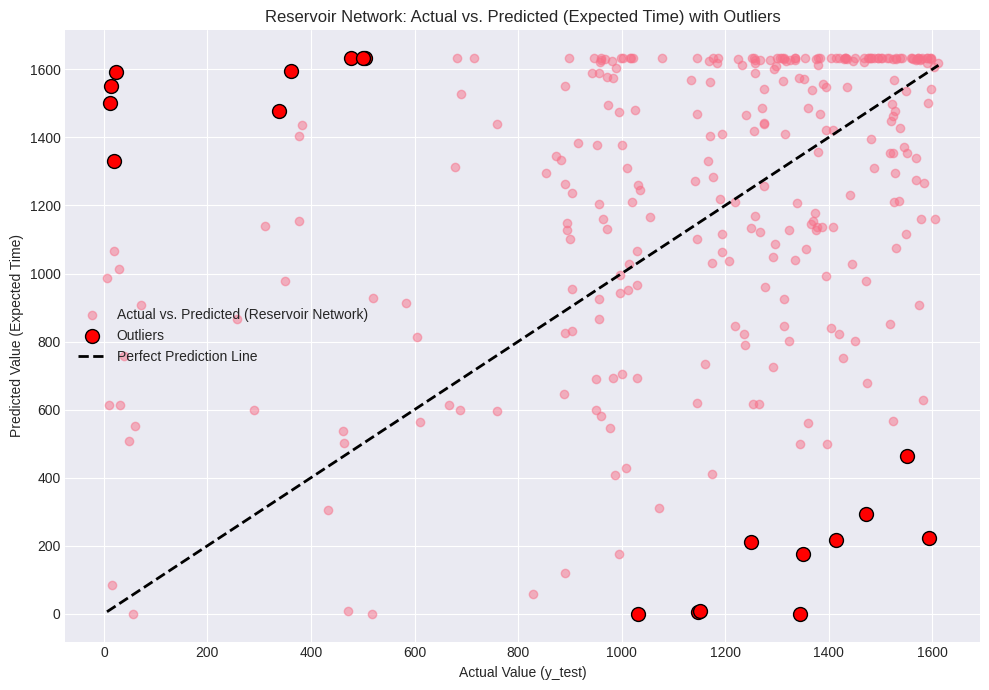


Number of outlier predictions: 19
Lower bound for residual outliers: -1123.95
Upper bound for residual outliers: 989.88

--- Outlier Samples (Actual vs. Predicted Expected Time) ---
      Actual    Predicted     Residual
721      338  1476.403210 -1138.403210
1244    1351   176.697580  1174.302420
730      477  1633.000000 -1156.000000
782     1344     0.000000  1344.000000
922     1552   462.435162  1089.564838
1191    1148     3.982108  1144.017892
854     1593   223.696514  1369.303486
1329      14  1551.779847 -1537.779847
299     1414   217.331548  1196.668452
206      504  1632.969940 -1128.969940
0       1152     9.220140  1142.779860
1335    1250   212.437237  1037.562763
13      1031     0.240489  1030.759511
570       20  1330.881140 -1310.881140
1314      11  1499.735584 -1488.735584
943     1473   294.252622  1178.747378
936      501  1631.896543 -1130.896543
286       24  1592.255368 -1568.255368
92       361  1594.033380 -1233.033380


In [49]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. Get predicted time scores for the test set using rn_model
predicted_rn_scores = rn_model.predict(X_test_sc).flatten()

# 2. Create a DataFrame with these scores for the cox_calibrator_rn
# The cox_calibrator_rn expects a DataFrame with a column named 'rn_time_prediction'
risk_df_for_calibrator_test_rn = pd.DataFrame({'rn_time_prediction': predicted_rn_scores}, index=y_test.index)

# 3. Use cox_calibrator_rn.predict_expectation to get a single predicted time for each test sample
predicted_time_rn = cox_calibrator_rn.predict_expectation(risk_df_for_calibrator_test_rn)

# Align predicted_time_rn with y_test
predicted_time_rn.index = y_test.index

# 4. Calculate residuals
residuals_rn = y_test - predicted_time_rn

# 5. Calculate IQR for residuals to identify outliers
Q1_res_rn = residuals_rn.quantile(0.25)
Q3_res_rn = residuals_rn.quantile(0.75)
IQR_res_rn = Q3_res_rn - Q1_res_rn

lower_bound_res_rn = Q1_res_rn - 1.5 * IQR_res_rn
upper_bound_res_rn = Q3_res_rn + 1.5 * IQR_res_rn

# Identify outlier residuals
outlier_mask_rn = (residuals_rn < lower_bound_res_rn) | (residuals_rn > upper_bound_res_rn)

outlier_y_test_rn = y_test[outlier_mask_rn]
outlier_predicted_time_rn = predicted_time_rn[outlier_mask_rn]

# 6. Plotting actual vs. predicted values with outliers highlighted
plt.figure(figsize=(10, 7))
plt.scatter(y_test, predicted_time_rn, alpha=0.5, label='Actual vs. Predicted (Reservoir Network)')
plt.scatter(outlier_y_test_rn, outlier_predicted_time_rn, color='red', s=100, label='Outliers', edgecolors='black')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, label='Perfect Prediction Line')
plt.xlabel('Actual Value (y_test)')
plt.ylabel('Predicted Value (Expected Time)')
plt.title('Reservoir Network: Actual vs. Predicted (Expected Time) with Outliers')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"\nNumber of outlier predictions: {len(outlier_y_test_rn)}")
print(f"Lower bound for residual outliers: {lower_bound_res_rn:.2f}")
print(f"Upper bound for residual outliers: {upper_bound_res_rn:.2f}")

print("\n--- Outlier Samples (Actual vs. Predicted Expected Time) ---")
outlier_df_rn = pd.DataFrame({'Actual': outlier_y_test_rn, 'Predicted': outlier_predicted_time_rn, 'Residual': residuals_rn[outlier_mask_rn]})
print(outlier_df_rn.to_string())

# Test how prediction works

In [50]:
original_test_sample_index = X_test.index[0]
original_test_sample = X_test.loc[[original_test_sample_index]]

print("\nOriginal (unscaled) features of the selected test sample:")
display(original_test_sample)



Original (unscaled) features of the selected test sample:


,doctor,age,af,dm,ckd,copd,insult,onco,severity,nstemi,...,pulm_cong,bmi,smoking,hb,leukoc,tromboc,t_chol,ldl,glu,crea
528,1,71.0,0,0,1,0,0,0,0,0,...,0,31.4,0,160.0,8.5,190.0,4.9,2.85,3.8,118.0


Selected test sample (first row of X_test_sc) with features:
     doctor       age        af        dm       ckd     copd    insult  \
0 -0.381865  0.609672 -0.413771 -0.596537  2.978062 -0.17806 -0.292682   

       onco  severity    nstemi  ...  pulm_cong     bmi   smoking        hb  \
0 -0.133235 -1.516123 -0.466252  ...  -0.307482  0.5421 -0.710634  1.064711   

     leukoc   tromboc    t_chol       ldl       glu      crea  
0 -0.432497 -0.624872 -0.332433 -0.375816 -0.890202  1.199192  

[1 rows x 30 columns]

Predicted XGBoost Cox risk score for the sample: 0.3900


<Figure size 1000x600 with 0 Axes>

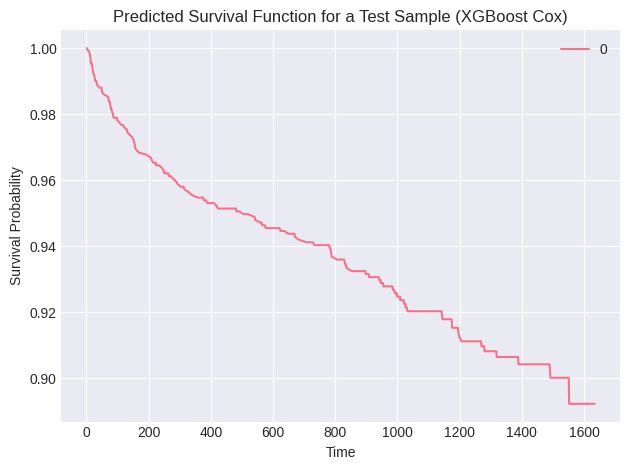


Interpretation: This plot shows the estimated probability of survival over time for the selected test sample, based on the XGBoost Cox model. The curve starts at 1 (100% survival) at time 0 and decreases as time progresses, indicating the likelihood of the event occurring.


In [51]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# --- Get a TEST sample ---
# For demonstration, let's select the first sample from the scaled test set
# X_test_sc is a numpy array, take the first row and reshape for single prediction
single_test_sample_scaled = X_test_sc[0].reshape(1, -1)

# Create a DataFrame for clarity, using the original feature names
single_test_sample_df = pd.DataFrame(single_test_sample_scaled, columns=original_gb_reg_features)

print(f"Selected test sample (first row of X_test_sc) with features:\n{single_test_sample_df}")

# --- Use XGBoost Cox (Gradient Boosting) to predict risk score ---
# The xgb_surv model was trained in a previous cell
predicted_risk_score_xgb = xgb_surv.predict(single_test_sample_scaled)

print(f"\nPredicted XGBoost Cox risk score for the sample: {predicted_risk_score_xgb[0]:.4f}")

# --- Evaluate survival function using the Cox calibrator ---
# The cox_calibrator was fitted using xgb_risk as a covariate
# We need to create a DataFrame with a 'xgb_risk' column for prediction
risk_data_for_calibrator_single = pd.DataFrame({
    'xgb_risk': predicted_risk_score_xgb
})

survival_function_xgb_sample = cox_calibrator.predict_survival_function(risk_data_for_calibrator_single)

# --- Plot the survival function ---
plt.figure(figsize=(10, 6))
survival_function_xgb_sample.plot()
plt.title('Predicted Survival Function for a Test Sample (XGBoost Cox)')
plt.xlabel('Time')
plt.ylabel('Survival Probability')
plt.grid(True)
plt.tight_layout()
plt.show()

print("\nInterpretation: This plot shows the estimated probability of survival over time for the selected test sample, based on the XGBoost Cox model. The curve starts at 1 (100% survival) at time 0 and decreases as time progresses, indicating the likelihood of the event occurring.")


SHAP values for the single test sample (first row of X_test_sc):
     doctor       age        af        dm       ckd      copd    insult  onco  severity    nstemi     stemi       llo    gender  ca_delay   sum_cad  stenting  total_revasc   ef_hosp       bpm     sysAP  pulm_cong      bmi   smoking        hb    leukoc   tromboc   t_chol       ldl       glu      crea
0 -0.085203  0.023669 -0.010769  0.029634  0.380359 -0.001202 -0.006832   0.0 -0.008055 -0.009601  0.005762 -0.558063  0.024082  0.018133  0.511142  0.019246     -0.009697 -0.107964 -0.292151 -0.056343   -0.09026 -0.03524 -0.029527 -0.404103 -0.098639  0.066149 -0.03168  0.030986 -0.420233  0.242484



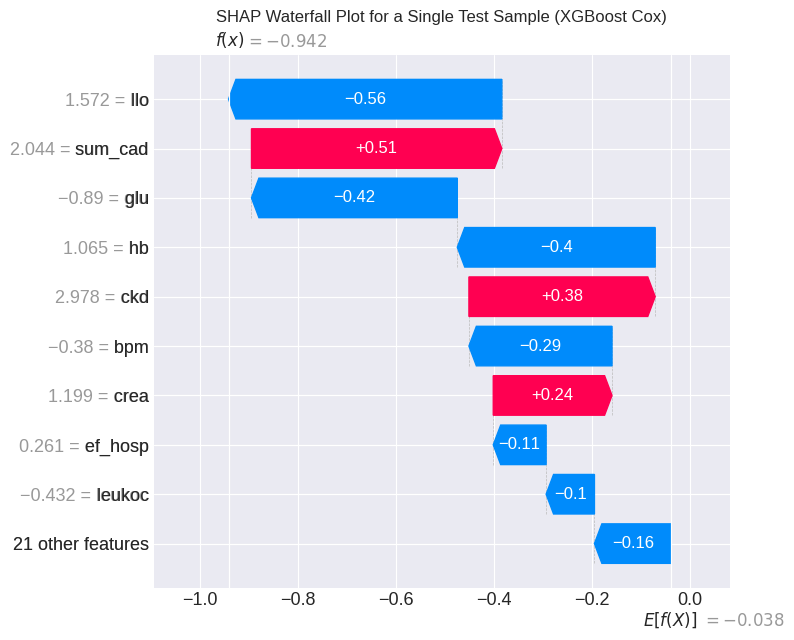


Interpretation of the Waterfall Plot:
- The Waterfall plot visualizes the individual feature contributions to a single prediction.
- The base value (E[f(x)]) is the average prediction across the dataset (or background dataset for KernelExplainer).
- Each bar shows how a feature's value pushes the prediction from the base value to the final output value (f(x)).
- Positive SHAP values (red bars) indicate features that increase the predicted risk score (meaning lower survival probability). 
- Negative SHAP values (blue bars) indicate features that decrease the predicted risk score (meaning higher survival probability).
- The length and direction of the bar indicate the magnitude and direction of the feature's impact.


In [52]:
import shap
import matplotlib.pyplot as plt

# Assuming xgb_surv is the trained XGBoost Cox model and single_test_sample_scaled
# is the scaled single sample (from PHjZTTz0fg_I)
# and original_gb_reg_features contains the feature names.

# Initialize the SHAP TreeExplainer for the XGBoost model
explainer_single_sample = shap.TreeExplainer(xgb_surv)

# Calculate SHAP values for the single test sample
# single_test_sample_scaled is a 2D array, so we need to pass it as is.
# shap_values_single will be a list of arrays if multi-output, or a single array if single-output.
shap_values_single = explainer_single_sample.shap_values(single_test_sample_scaled)

# Ensure shap_values_single is a single array for single-output models
# If it's a list with one element, extract it.
if isinstance(shap_values_single, list):
    shap_values_single = shap_values_single[0]

# Ensure single_test_sample_df (the DataFrame version of the single scaled sample)
# is available from the previous cell or recreate it for context.
# It was created in PHjZTTz0fg_I, but let's make sure it's accessible.
single_test_sample_df = pd.DataFrame(single_test_sample_scaled, columns=original_gb_reg_features)

print(f"\nSHAP values for the single test sample (first row of X_test_sc):\n{pd.DataFrame(shap_values_single.reshape(1, -1), columns=original_gb_reg_features).to_string()}\n")

# Visualize the SHAP values for this single sample using a waterfall plot
shap.initjs()
plt.figure(figsize=(10, 6))
shap.plots.waterfall(shap.Explanation(
    values=shap_values_single[0], # Corrected: Pass the single explanation from the array
    base_values=explainer_single_sample.expected_value,
    data=single_test_sample_df.iloc[0],
    feature_names=original_gb_reg_features
), show=False) # show=False to allow plt.tight_layout()
plt.title('SHAP Waterfall Plot for a Single Test Sample (XGBoost Cox)')
plt.tight_layout()
plt.show()

print("\nInterpretation of the Waterfall Plot:")
print("- The Waterfall plot visualizes the individual feature contributions to a single prediction.")
print("- The base value (E[f(x)]) is the average prediction across the dataset (or background dataset for KernelExplainer).")
print("- Each bar shows how a feature's value pushes the prediction from the base value to the final output value (f(x)).")
print("- Positive SHAP values (red bars) indicate features that increase the predicted risk score (meaning lower survival probability). ")
print("- Negative SHAP values (blue bars) indicate features that decrease the predicted risk score (meaning higher survival probability).")
print("- The length and direction of the bar indicate the magnitude and direction of the feature's impact.")